In [41]:
import pandas as pd
from datetime import datetime, timedelta

# Load the Excel file as a dataframe
file_path = r'Z:\HTOC\Data_Analytics\Data\Threat Assessment Scores\Threat_Assessment_Scores.xlsx'
df = pd.read_excel(file_path)

# Display basic information about the dataframe before filtering
print("=" * 60)
print("DATA LOADING AND FILTERING")
print("=" * 60)
print(f"\nOriginal Dataset Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Filter for indicators observed in the last 30 days
print(f"\n{'='*60}")
print("FILTERING: Indicators Last Observed in Last 30 Days")
print("=" * 60)

# Convert 'Last Observed' to datetime if not already
df['Last Observed'] = pd.to_datetime(df['Last Observed'], errors='coerce')

# Calculate days since last observed
today = pd.Timestamp.now()
df['Days_Since_Observed'] = (today - df['Last Observed']).dt.days

# Filter for last 30 days
df_original = df.copy()  # Keep original for reference
df = df[df['Days_Since_Observed'] <= 30].copy()

print(f"\nFilter Applied: Last Observed ≤ 30 days ago")
print(f"Original Indicators: {len(df_original):,}")
print(f"Filtered Indicators (Last 30 Days): {len(df):,}")
print(f"Percentage Retained: {len(df)/len(df_original)*100:.2f}%")

# Display basic information about the filtered dataframe
print(f"\n{'='*60}")
print("FILTERED DATASET INFORMATION")
print("=" * 60)
print(f"\nShape: {df.shape}")
print(f"\nDate Range:")
if len(df) > 0:
    print(f"  Most Recent: {df['Last Observed'].max().strftime('%Y-%m-%d')}")
    print(f"  Oldest (in 30-day window): {df['Last Observed'].min().strftime('%Y-%m-%d')}")
    print(f"  Days Since Observed Range: {df['Days_Since_Observed'].min():.0f} to {df['Days_Since_Observed'].max():.0f} days")
else:
    print("  No indicators found in the last 30 days")

print(f"\nFirst few rows of filtered data:")
df.head()


DATA LOADING AND FILTERING

Original Dataset Shape: (1868, 15)
Columns: ['Indicator', 'Last Observed', 'Indicator Type', 'VirusTotal Malicious Score', 'Observation Yearly Count', 'ThreatConnect Rating', 'Observation Penalty Multiplier', 'Botnet Flag', 'False Positives', 'Partners', 'calScore', 'ThreatConnect Threat Score', 'Threat Score', 'Severity', 'Score Explanation']

FILTERING: Indicators Last Observed in Last 30 Days

Filter Applied: Last Observed ≤ 30 days ago
Original Indicators: 1,868
Filtered Indicators (Last 30 Days): 1,535
Percentage Retained: 82.17%

FILTERED DATASET INFORMATION

Shape: (1535, 16)

Date Range:
  Most Recent: 2025-12-04
  Oldest (in 30-day window): 2025-11-04
  Days Since Observed Range: 0 to 30 days

First few rows of filtered data:


,Indicator,Last Observed,Indicator Type,VirusTotal Malicious Score,Observation Yearly Count,ThreatConnect Rating,Observation Penalty Multiplier,Botnet Flag,False Positives,Partners,calScore,ThreatConnect Threat Score,Threat Score,Severity,Score Explanation,Days_Since_Observed
0,1-you.njalla.no,2025-11-26,Host,0,23,5,0.998740,0,0,"DHA, NIH, VA",180.0,590,143,low,Severity: low. Top drivers: TC confidence; TC ...,8
1,1.54.101.176,2025-12-04,Address,0,1,1,0.999945,1,0,DHA,170.0,255,138,low,Severity: low. Top drivers: TOR activity; TC c...,0
2,101.71.130.99,2025-12-04,Address,10,50,3,0.997260,0,0,"CMS, DHA, FDA, HHS, IHS, NIH, OS",740.0,648,393,medium,Severity: medium. Top drivers: VT malicious (l...,0
3,101.89.174.236,2025-11-12,Address,9,176,3,0.990356,0,0,"CMS, DHA, FDA, HHS, HRSA, IHS, NIH, OS",180.0,433,306,medium,Severity: medium. Top drivers: VT malicious (l...,22
4,102.0.5.152,2025-12-02,Address,1,16,1,0.999123,1,0,"CMS, DHA, HRSA, VA",180.0,288,170,low,Severity: low. Top drivers: TOR activity; TC c...,2


In [42]:
import os
import pandas as pd
from datetime import datetime, timedelta

# Base file path with placeholder for date
base_path = r"Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d{date}.csv"
#base_path = r"C:\Users\jaskew\Documents\project_repository\data\raw\ObservationDataFiles\htoc_opdiv_obs_d{date}.csv"
date_format = "%Y%m%d"

def get_file_paths(base_path, days=30):
    """ Generate file paths for the last `days` days using list comprehension. """
    today = datetime.utcnow()
    dates_to_pull = [(today - timedelta(days=i)).strftime(date_format) for i in range(days)]
    
    # Construct file paths
    file_paths = [base_path.format(date=dt) for dt in dates_to_pull]
    
    # Filter for existing files
    existing_files = [file_path for file_path in file_paths if os.path.exists(file_path)]
    
    if not existing_files:
        display("No files found for the specified date range.")
    else:
        display(f"Files to be loaded: {existing_files}")
    
    return existing_files

def load_observed_data(file_paths):
    """ Load and concatenate observed data from multiple files. """
    data_frames = []

    for file_path in file_paths:
        try:
            df = pd.read_csv(file_path)
            data_frames.append(df)
        except Exception as e:
            display(f"Error reading file {file_path}: {e}")
    
    # Concatenate data
    if data_frames:
        observed_data_df = pd.concat(data_frames, ignore_index=True)
        display(f"Loaded data from {len(data_frames)} files.")
    else:
        observed_data_df = pd.DataFrame()

    return observed_data_df

# Example Usage:
# Fetch file paths for the last 3 days
file_paths = get_file_paths(base_path, days=30)

# Load observed data
observed_data_df = load_observed_data(file_paths)



C:\Users\jaskew\AppData\Local\Temp\ipykernel_20396\3136746881.py:12: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  today = datetime.utcnow()


"Files to be loaded: ['Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20251204.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20251203.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20251202.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20251201.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20251130.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20251129.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20251128.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20251127.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20251126.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20251125.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20251124.csv', 'Z:/HTOC/Data_Analytics/Data/OpDiv_Observations/htoc_opdiv_obs_d20251123.csv', 'Z:/HTOC/Data_Analytics/Data/O

'Loaded data from 30 files.'

In [43]:
observed_data_df[observed_data_df['indicator'] == '129.227.46.163']

,indicator,API_UserName,obs_date,OpDiv,indicator_key,observations,curr_date
22476,129.227.46.163,20790633968691748718,2025-11-29,DHA,129.227.46.163_DHA,53,2025-11-29
27127,129.227.46.163,20790633968691748718,2025-11-28,DHA,129.227.46.163_DHA,266,2025-11-28
36309,129.227.46.163,20790633968691748718,2025-11-26,DHA,129.227.46.163_DHA,151,2025-11-26
40781,129.227.46.163,20790633968691748718,2025-11-25,DHA,129.227.46.163_DHA,220,2025-11-25
45235,129.227.46.163,20790633968691748718,2025-11-24,DHA,129.227.46.163_DHA,60,2025-11-24
49486,129.227.46.163,20790633968691748718,2025-11-23,DHA,129.227.46.163_DHA,42,2025-11-23
53428,129.227.46.163,20790633968691748718,2025-11-22,DHA,129.227.46.163_DHA,603,2025-11-22
91954,129.227.46.163,20790633968691748718,2025-11-13,DHA,129.227.46.163_DHA,3,2025-11-13


In [44]:
# Create a comparison of Partners: All-Time vs Last 30 Days
# df['Partners'] = All-time partners (from Excel file)
# observed_data_df = Last 30 days observations only

# detect column names in observed_data_df (robust to capitalization)
indicator_col_obs = next((c for c in observed_data_df.columns if c.lower() == 'indicator'), None)
opdiv_col = next((c for c in observed_data_df.columns if c.lower() == 'opdiv'), None)

if indicator_col_obs is None or opdiv_col is None:
    raise ValueError("observed_data_df must contain columns named 'indicator' and 'OpDiv' (case-insensitive).")

# build LAST 30 DAYS partners mapping from observed_data_df
obs = observed_data_df[[indicator_col_obs, opdiv_col]].copy()
obs[indicator_col_obs] = obs[indicator_col_obs].astype(str).str.strip()
obs[opdiv_col] = obs[opdiv_col].astype(str).str.strip()

last30_partners = (
    obs.dropna(subset=[opdiv_col])
       .groupby(indicator_col_obs)[opdiv_col]
       .apply(lambda vals: ', '.join(sorted({v.strip() for v in vals if str(v).strip() != ''})))
       .reset_index()
)
last30_partners.columns = ['Indicator', 'Partners_Last30']

# prepare ALL-TIME partners (from df - the Excel file partners)
alltime_summary = df[['Indicator', 'Partners']].copy()
alltime_summary = alltime_summary.rename(columns={'Partners': 'Partners_AllTime'})
alltime_summary['Partners_AllTime'] = alltime_summary['Partners_AllTime'].fillna('No Partner')

# merge to get both columns in one dataframe
partners_summary_df = alltime_summary.merge(last30_partners, on='Indicator', how='left')
partners_summary_df['Partners_Last30'] = partners_summary_df['Partners_Last30'].fillna('No Partner')

# optional: add simple partner counts
def count_partners(s):
    if pd.isna(s) or str(s).strip() in ['', 'No Partner', 'nan']:
        return 0
    return len([p for p in str(s).split(',') if p.strip() != ''])

partners_summary_df['Partner_Count_AllTime'] = partners_summary_df['Partners_AllTime'].apply(count_partners)
partners_summary_df['Partner_Count_Last30'] = partners_summary_df['Partners_Last30'].apply(count_partners)

# final columns in logical order: AllTime, Last30, Counts
partners_summary_df = partners_summary_df[['Indicator', 'Partners_AllTime', 'Partners_Last30',
                                           'Partner_Count_AllTime', 'Partner_Count_Last30']]

# show results
partners_summary_df.head(50)

,Indicator,Partners_AllTime,Partners_Last30,Partner_Count_AllTime,Partner_Count_Last30
0,1-you.njalla.no,"DHA, NIH, VA","DHA, NIH, VA",3,3
1,1.54.101.176,DHA,DHA,1,1
2,101.71.130.99,"CMS, DHA, FDA, HHS, IHS, NIH, OS","CMS, DHA, FDA, HHS, IHS, NIH, OS",7,7
3,101.89.174.236,"CMS, DHA, FDA, HHS, HRSA, IHS, NIH, OS","CMS, DHA, FDA, HHS, HRSA, OS",8,6
4,102.0.5.152,"CMS, DHA, HRSA, VA","DHA, HRSA",4,2
5,102.209.18.96,"FDA, HRSA, VA",HRSA,3,1
6,103.114.96.246,"CMS, DHA, HRSA, NIH, OS, VA","DHA, HRSA",6,2
7,103.133.60.12,"DHA, FDA, HHS, HRSA, VA","DHA, HRSA",5,2
8,103.133.61.182,"DHA, FDA, HRSA, NIH, VA",DHA,5,1
9,103.136.147.130,"DHA, VA","DHA, VA",2,2


In [45]:
# Override df['Partners'] with Partners_Last30 (actual last 30 days from observed_data_df)
# Create mapping from partners_summary_df
partners_mapping = partners_summary_df.set_index('Indicator')['Partners_Last30'].to_dict()

# Override Partners column in df
df['Partners_Original'] = df['Partners'].copy()  # Keep backup of original
df['Partners'] = df['Indicator'].map(partners_mapping).fillna(df['Partners'])

# Show comparison of changes
comparison = df[['Indicator', 'Partners_Original', 'Partners']]
comparison

,Indicator,Partners_Original,Partners
0,1-you.njalla.no,"DHA, NIH, VA","DHA, NIH, VA"
1,1.54.101.176,DHA,DHA
2,101.71.130.99,"CMS, DHA, FDA, HHS, IHS, NIH, OS","CMS, DHA, FDA, HHS, IHS, NIH, OS"
3,101.89.174.236,"CMS, DHA, FDA, HHS, HRSA, IHS, NIH, OS","CMS, DHA, FDA, HHS, HRSA, OS"
4,102.0.5.152,"CMS, DHA, HRSA, VA","DHA, HRSA"
...,...,...,...
1530,www.prosinthecity.com,"CMS, DHA, NIH, OS",NIH
1531,www.shorturl.at/,"CDC, FDA","CDC, FDA"
1532,www.sthda.com,"CMS, DHA, FDA, HRSA, IHS, NIH, OS, VA","CMS, NIH"
1533,yourpensionmeeting.com,"CMS, DHA, FDA, NIH, VA","FDA, VA"


THREAT SCORE DISTRIBUTION ANALYSIS

1. Summary Statistics:
------------------------------------------------------------
count    1535.000000
mean      262.894463
std       125.604133
min        20.000000
25%       181.000000
50%       240.000000
75%       329.000000
max       853.000000
Name: Threat Score, dtype: float64

2. Additional Statistics:
------------------------------------------------------------
Total Indicators: 1535
Mean Threat Score: 262.89
Median Threat Score: 240.00
Standard Deviation: 125.60
Min Threat Score: 20.00
Max Threat Score: 853.00
Range: 833.00

3. Percentiles:
------------------------------------------------------------
10th percentile: 138.00
25th percentile: 181.00
50th percentile: 240.00
75th percentile: 329.00
90th percentile: 389.60
95th percentile: 499.00
99th percentile: 797.66


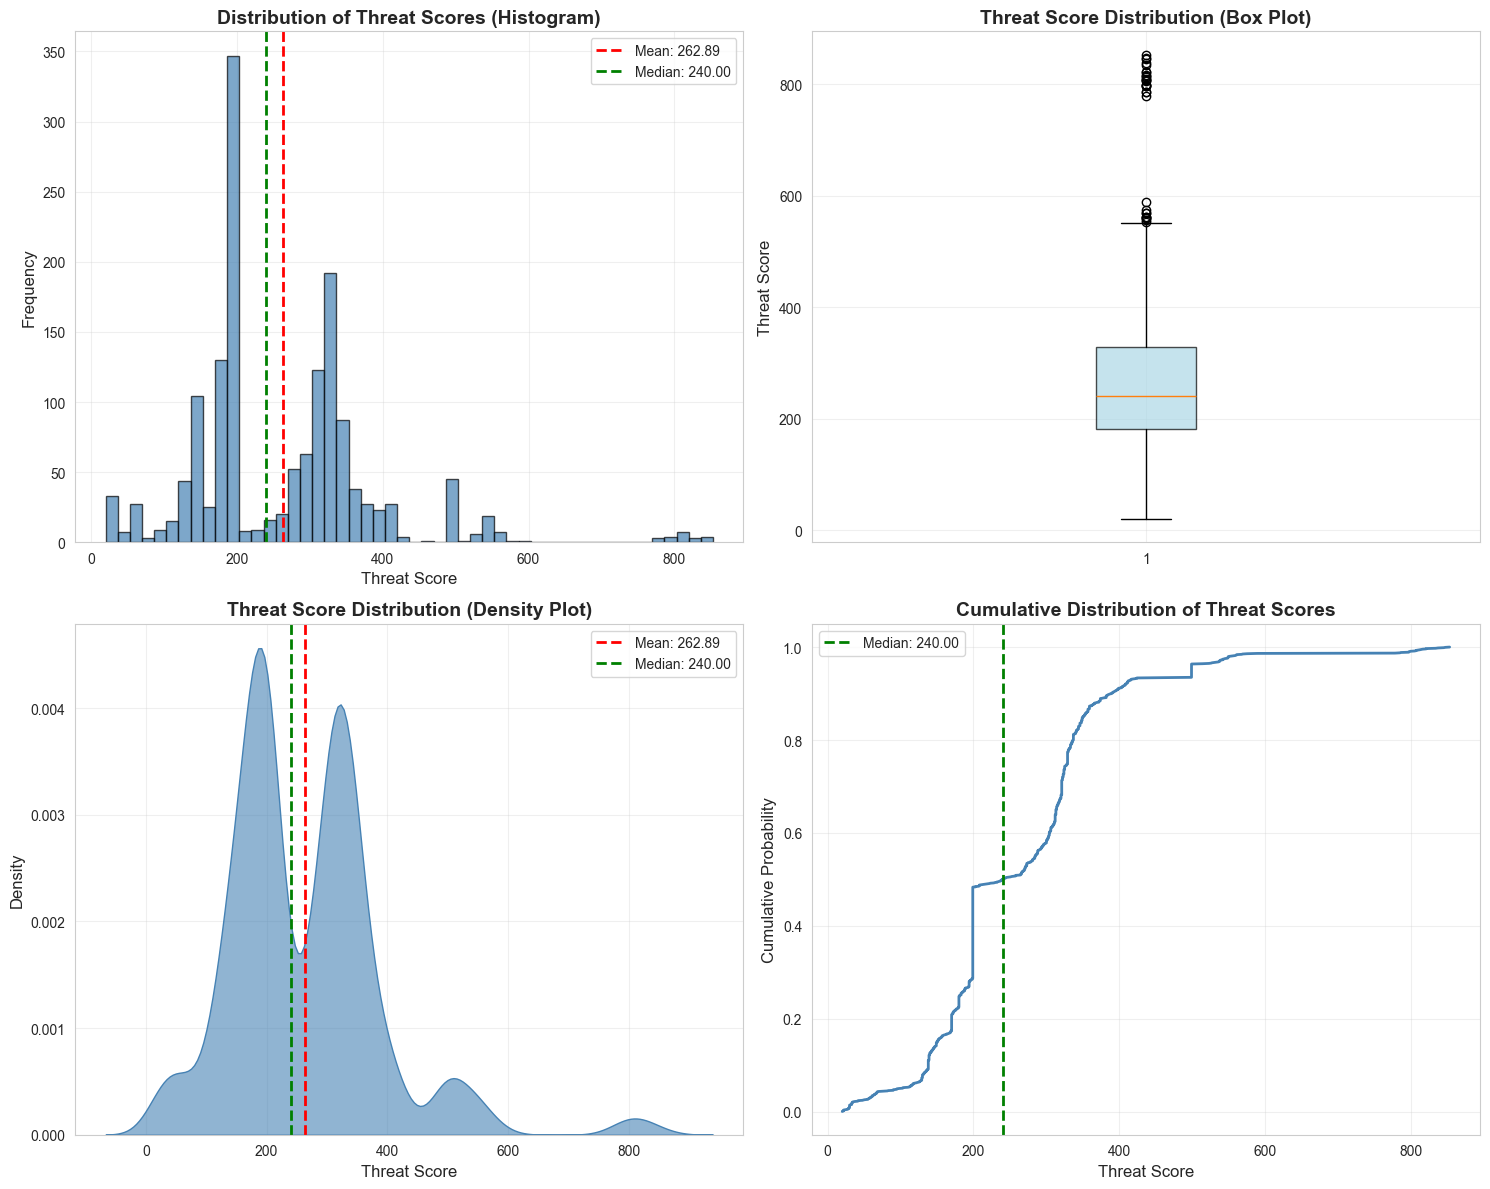


4. Score Range Breakdown:
------------------------------------------------------------
low: 742 indicators (48.34%)
medium: 737 indicators (48.01%)
high: 42 indicators (2.74%)
critical: 14 indicators (0.91%)


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Distribution of Threat Scores
print("=" * 60)
print("THREAT SCORE DISTRIBUTION ANALYSIS")
print("=" * 60)

# Summary Statistics
print("\n1. Summary Statistics:")
print("-" * 60)
print(df['Threat Score'].describe())

# Additional statistics
print(f"\n2. Additional Statistics:")
print("-" * 60)
print(f"Total Indicators: {len(df)}")
print(f"Mean Threat Score: {df['Threat Score'].mean():.2f}")
print(f"Median Threat Score: {df['Threat Score'].median():.2f}")
print(f"Standard Deviation: {df['Threat Score'].std():.2f}")
print(f"Min Threat Score: {df['Threat Score'].min():.2f}")
print(f"Max Threat Score: {df['Threat Score'].max():.2f}")
print(f"Range: {df['Threat Score'].max() - df['Threat Score'].min():.2f}")

# Percentiles
print(f"\n3. Percentiles:")
print("-" * 60)
percentiles = [10, 25, 50, 75, 90, 95, 99]
for p in percentiles:
    print(f"{p}th percentile: {np.percentile(df['Threat Score'], p):.2f}")

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Histogram
axes[0, 0].hist(df['Threat Score'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(df['Threat Score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Threat Score"].mean():.2f}')
axes[0, 0].axvline(df['Threat Score'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["Threat Score"].median():.2f}')
axes[0, 0].set_xlabel('Threat Score', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Distribution of Threat Scores (Histogram)', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Box Plot
axes[0, 1].boxplot(df['Threat Score'], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', alpha=0.7))
axes[0, 1].set_ylabel('Threat Score', fontsize=12)
axes[0, 1].set_title('Threat Score Distribution (Box Plot)', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Density Plot (KDE)
sns.kdeplot(data=df, x='Threat Score', ax=axes[1, 0], fill=True, color='steelblue', alpha=0.6)
axes[1, 0].axvline(df['Threat Score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Threat Score"].mean():.2f}')
axes[1, 0].axvline(df['Threat Score'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["Threat Score"].median():.2f}')
axes[1, 0].set_xlabel('Threat Score', fontsize=12)
axes[1, 0].set_ylabel('Density', fontsize=12)
axes[1, 0].set_title('Threat Score Distribution (Density Plot)', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Cumulative Distribution
sorted_scores = np.sort(df['Threat Score'])
cumulative = np.arange(1, len(sorted_scores) + 1) / len(sorted_scores)
axes[1, 1].plot(sorted_scores, cumulative, linewidth=2, color='steelblue')
axes[1, 1].axvline(df['Threat Score'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["Threat Score"].median():.2f}')
axes[1, 1].set_xlabel('Threat Score', fontsize=12)
axes[1, 1].set_ylabel('Cumulative Probability', fontsize=12)
axes[1, 1].set_title('Cumulative Distribution of Threat Scores', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Score ranges breakdown
print(f"\n4. Score Range Breakdown:")
print("-" * 60)
scoring_bins = [0, 200, 500, 800, 1001]
label_bins = ['low', 'medium', 'high', 'critical']
df['Score_Range'] = pd.cut(df['Threat Score'], bins=scoring_bins, labels=label_bins, include_lowest=True)
score_distribution = df['Score_Range'].value_counts().sort_index()
for range_val, count in score_distribution.items():
    percentage = (count / len(df)) * 100
    print(f"{range_val}: {count} indicators ({percentage:.2f}%)")

THREAT SCORE DISTRIBUTION BY PARTNERS

1. Data Overview:
------------------------------------------------------------
Total indicators: 1535
Indicators with Partners: 1535
Indicators without Partners: 0

2. Sample Partner Values:
------------------------------------------------------------
1. DHA, NIH, VA
2. DHA
3. CMS, DHA, FDA, HHS, IHS, NIH, OS
4. CMS, DHA, FDA, HHS, HRSA, OS
5. DHA, HRSA
6. HRSA
7. DHA, HRSA
8. DHA, HRSA
9. DHA
10. DHA, VA

3. Partner Statistics:
------------------------------------------------------------
            Count    Mean  Median     Std  Min  Max
Partners                                           
CMS           936  304.81   316.0  122.26   20  853
DHA           932  265.72   283.5   89.67   34  821
VA            875  286.28   312.0   94.15   42  837
OS            845  318.35   321.0  105.72  117  853
FDA           811  316.03   321.0  105.53   55  845
HRSA          721  295.65   306.0  116.66  103  853
IHS           698  300.96   320.0   79.24   64  557

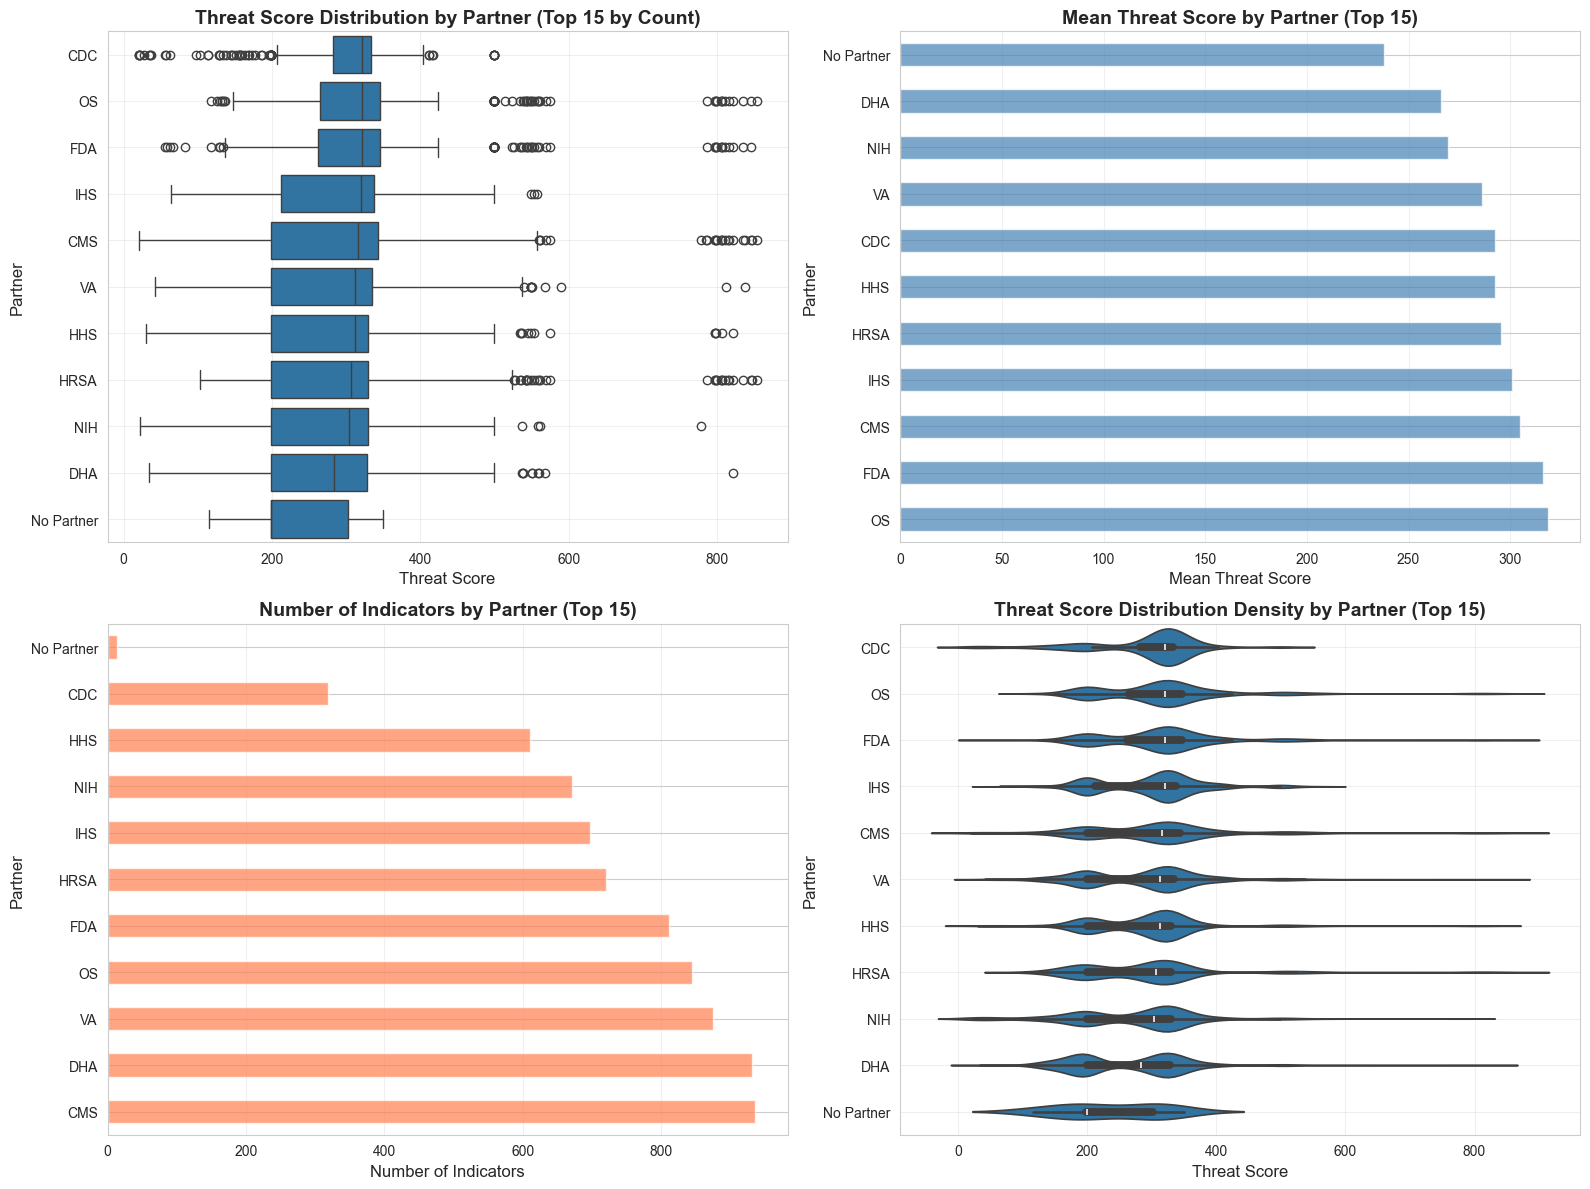


4. Detailed Breakdown by Partner:
------------------------------------------------------------

CMS:
  Count: 936
  Mean: 304.81
  Median: 316.00
  Std Dev: 122.26
  Range: 20.00 - 853.00

DHA:
  Count: 932
  Mean: 265.72
  Median: 283.50
  Std Dev: 89.67
  Range: 34.00 - 821.00

VA:
  Count: 875
  Mean: 286.28
  Median: 312.00
  Std Dev: 94.15
  Range: 42.00 - 837.00

OS:
  Count: 845
  Mean: 318.35
  Median: 321.00
  Std Dev: 105.72
  Range: 117.00 - 853.00

FDA:
  Count: 811
  Mean: 316.03
  Median: 321.00
  Std Dev: 105.53
  Range: 55.00 - 845.00

HRSA:
  Count: 721
  Mean: 295.65
  Median: 306.00
  Std Dev: 116.66
  Range: 103.00 - 853.00

IHS:
  Count: 698
  Mean: 300.96
  Median: 320.00
  Std Dev: 79.24
  Range: 64.00 - 557.00

NIH:
  Count: 671
  Mean: 269.39
  Median: 304.00
  Std Dev: 98.16
  Range: 22.00 - 778.00

HHS:
  Count: 610
  Mean: 292.48
  Median: 312.00
  Std Dev: 91.14
  Range: 30.00 - 821.00

CDC:
  Count: 319
  Mean: 292.47
  Median: 321.00
  Std Dev: 83.89
  R

In [47]:
# Distribution of Threat Scores by Partners
print("=" * 60)
print("THREAT SCORE DISTRIBUTION BY PARTNERS")
print("=" * 60)

# Check for missing values and data types
print("\n1. Data Overview:")
print("-" * 60)
print(f"Total indicators: {len(df)}")
print(f"Indicators with Partners: {df['Partners'].notna().sum()}")
print(f"Indicators without Partners: {df['Partners'].isna().sum()}")

# Handle missing partners
df_partners = df.copy()
df_partners['Partners'] = df_partners['Partners'].fillna('No Partner')

# Check if partners are comma-separated or single values
# Sample a few values to understand the format
print(f"\n2. Sample Partner Values:")
print("-" * 60)
sample_partners = df_partners['Partners'].dropna().head(10)
for idx, val in enumerate(sample_partners, 1):
    print(f"{idx}. {val}")

# Handle multiple partners (if comma-separated)
# Expand rows for indicators with multiple partners
df_expanded = df_partners.copy()
if df_partners['Partners'].astype(str).str.contains(',').any():
    # Split partners and expand
    df_expanded = df_partners.assign(Partners=df_partners['Partners'].astype(str).str.split(',')).explode('Partners')
    df_expanded['Partners'] = df_expanded['Partners'].str.strip()

# Partner statistics
print(f"\n3. Partner Statistics:")
print("-" * 60)
partner_stats = df_expanded.groupby('Partners')['Threat Score'].agg([
    ('Count', 'count'),
    ('Mean', 'mean'),
    ('Median', 'median'),
    ('Std', 'std'),
    ('Min', 'min'),
    ('Max', 'max')
]).round(2).sort_values('Count', ascending=False)

print(partner_stats)

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Box plot by partner (top N partners by count)
top_n = 15  # Show top 15 partners
top_partners = df_expanded['Partners'].value_counts().head(top_n).index
df_top = df_expanded[df_expanded['Partners'].isin(top_partners)]

if len(df_top) > 0:
    # Order by median score
    partner_order = df_top.groupby('Partners')['Threat Score'].median().sort_values(ascending=False).index
    
    sns.boxplot(data=df_top, x='Threat Score', y='Partners', order=partner_order, ax=axes[0, 0])
    axes[0, 0].set_title(f'Threat Score Distribution by Partner (Top {top_n} by Count)', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Threat Score', fontsize=12)
    axes[0, 0].set_ylabel('Partner', fontsize=12)
    axes[0, 0].grid(True, alpha=0.3)

# 2. Mean threat score by partner (bar chart)
partner_means = df_expanded.groupby('Partners')['Threat Score'].mean().sort_values(ascending=False).head(top_n)
partner_means.plot(kind='barh', ax=axes[0, 1], color='steelblue', alpha=0.7)
axes[0, 1].set_title(f'Mean Threat Score by Partner (Top {top_n})', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Mean Threat Score', fontsize=12)
axes[0, 1].set_ylabel('Partner', fontsize=12)
axes[0, 1].grid(True, alpha=0.3, axis='x')

# 3. Count of indicators by partner
partner_counts = df_expanded['Partners'].value_counts().head(top_n)
partner_counts.plot(kind='barh', ax=axes[1, 0], color='coral', alpha=0.7)
axes[1, 0].set_title(f'Number of Indicators by Partner (Top {top_n})', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Number of Indicators', fontsize=12)
axes[1, 0].set_ylabel('Partner', fontsize=12)
axes[1, 0].grid(True, alpha=0.3, axis='x')

# 4. Violin plot for top partners
if len(df_top) > 0:
    sns.violinplot(data=df_top, x='Threat Score', y='Partners', order=partner_order, ax=axes[1, 1])
    axes[1, 1].set_title(f'Threat Score Distribution Density by Partner (Top {top_n})', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Threat Score', fontsize=12)
    axes[1, 1].set_ylabel('Partner', fontsize=12)
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Detailed breakdown by partner
print(f"\n4. Detailed Breakdown by Partner:")
print("-" * 60)
for partner in partner_stats.head(20).index:
    partner_data = df_expanded[df_expanded['Partners'] == partner]['Threat Score']
    print(f"\n{partner}:")
    print(f"  Count: {len(partner_data)}")
    print(f"  Mean: {partner_data.mean():.2f}")
    print(f"  Median: {partner_data.median():.2f}")
    print(f"  Std Dev: {partner_data.std():.2f}")
    print(f"  Range: {partner_data.min():.2f} - {partner_data.max():.2f}")


TOP 5% AND TOP 10% THREAT SCORES ANALYSIS

1. Overview:
------------------------------------------------------------
Total Indicators: 1535
Top 10% Count: 154 indicators
Top 5% Count: 77 indicators

Score Threshold for Top 10%: 390.00
Score Threshold for Top 5%: 499.00

2. Statistics - Top 10%:
------------------------------------------------------------
Mean Score: 520.76
Median Score: 499.00
Min Score: 390.00
Max Score: 853.00
Std Deviation: 129.16

3. Statistics - Top 5%:
------------------------------------------------------------
Mean Score: 606.18
Median Score: 545.00
Min Score: 499.00
Max Score: 853.00
Std Deviation: 129.74

4. Top 10% Indicators (154 indicators):
------------------------------------------------------------
      Indicator Indicator Type                                        Partners  Threat Score Severity  VirusTotal Malicious Score  Observation Yearly Count  ThreatConnect Rating
  85.93.218.204        Address                                   CMS, HRSA, OS   

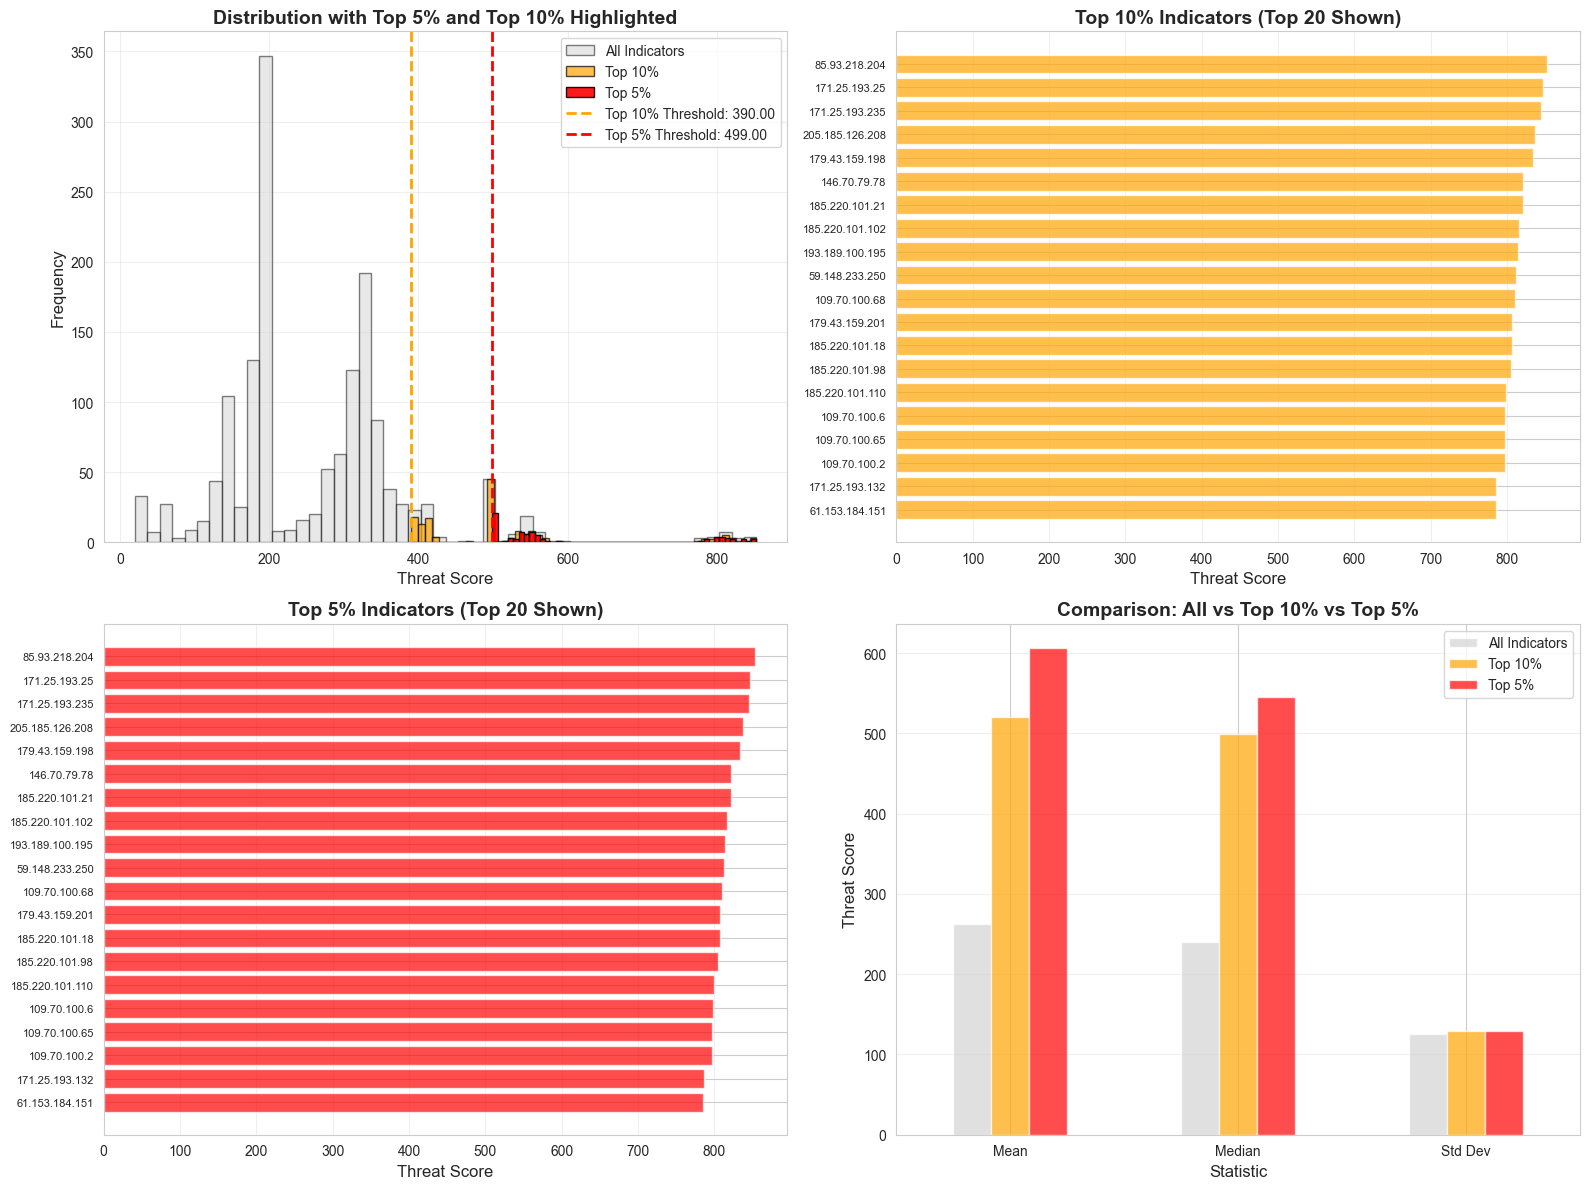


6. Top 10% Breakdown by Severity:
------------------------------------------------------------
medium: 98 indicators (63.64%)
high: 42 indicators (27.27%)
critical: 14 indicators (9.09%)

7. Top 5% Breakdown by Severity:
------------------------------------------------------------
high: 42 indicators (54.55%)
medium: 21 indicators (27.27%)
critical: 14 indicators (18.18%)

8. Top 10% Breakdown by Indicator Type:
------------------------------------------------------------
Address: 154 indicators (100.00%)

9. Top 5% Breakdown by Indicator Type:
------------------------------------------------------------
Address: 77 indicators (100.00%)

10. Partner Analysis for Top 10% Indicators:

10a. Partner Frequency in Top 10% Indicators:
------------------------------------------------------------
CMS: 129 observations (18.07%)
OS: 122 observations (17.09%)
FDA: 111 observations (15.55%)
VA: 86 observations (12.04%)
IHS: 73 observations (10.22%)
HRSA: 59 observations (8.26%)
DHA: 50 observation

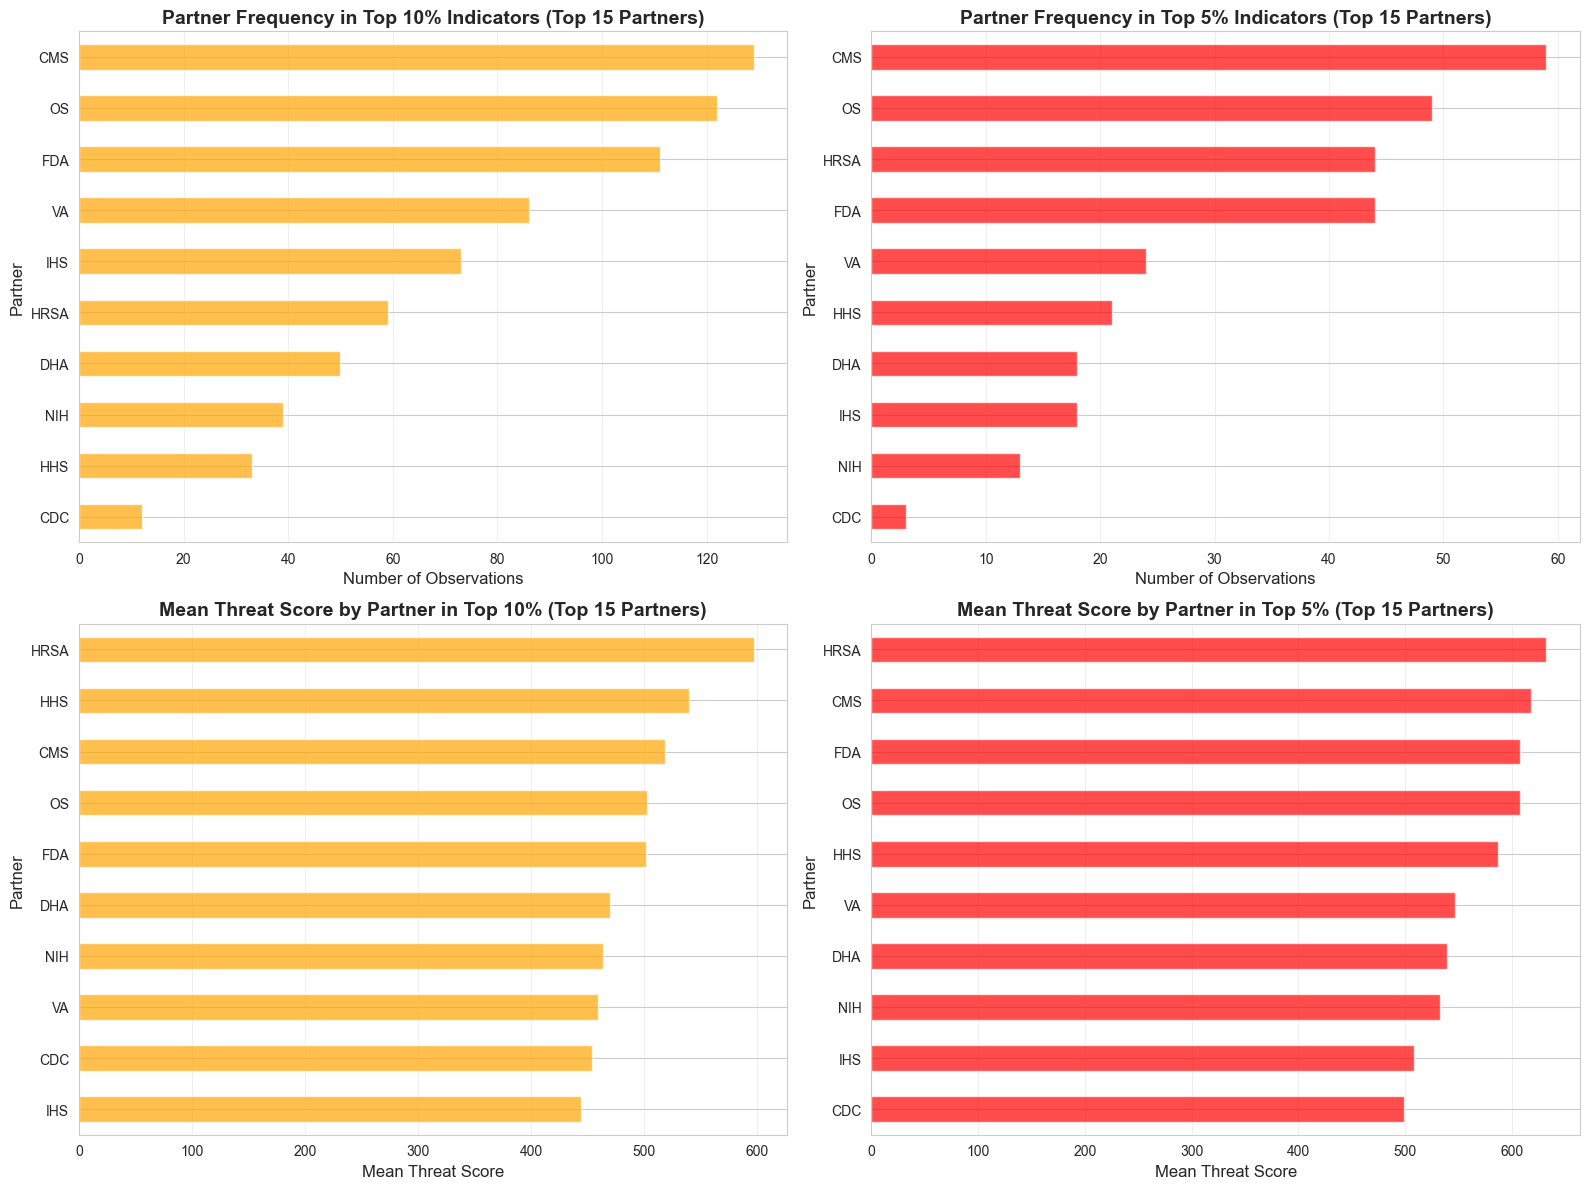


12. Partner Comparison: Top Percentiles vs Overall:

Top 15 Partners by Over-representation in Top 10%:
------------------------------------------------------------
            Overall_Pct  Top_10_Pct  Top_10_Over_Rep
Partners                                            
OS                11.37       17.09             5.72
CMS               12.60       18.07             5.47
FDA               10.91       15.55             4.63
IHS                9.39       10.22             0.83
VA                11.77       12.04             0.27
No Partner         0.17        0.00            -0.17
HRSA               9.70        8.26            -1.44
CDC                4.29        1.68            -2.61
NIH                9.03        5.46            -3.57
HHS                8.21        4.62            -3.59
DHA               12.54        7.00            -5.54

Top 15 Partners by Over-representation in Top 5%:
------------------------------------------------------------
            Overall_Pct  Top_5_Pc

In [48]:
# Top 5% and Top 10% of Threat Scores and Indicators
print("=" * 60)
print("TOP 5% AND TOP 10% THREAT SCORES ANALYSIS")
print("=" * 60)

# Sort dataframe by Threat Score in descending order
df_sorted = df.sort_values('Threat Score', ascending=False).reset_index(drop=True)

# Calculate thresholds
total_indicators = len(df_sorted)
top_10_percent_count = int(np.ceil(total_indicators * 0.10))
top_5_percent_count = int(np.ceil(total_indicators * 0.05))

# Get top 10% and top 5%
top_10_percent = df_sorted.head(top_10_percent_count)
top_5_percent = df_sorted.head(top_5_percent_count)

# Calculate score thresholds
score_threshold_10 = top_10_percent['Threat Score'].min()
score_threshold_5 = top_5_percent['Threat Score'].min()

print(f"\n1. Overview:")
print("-" * 60)
print(f"Total Indicators: {total_indicators}")
print(f"Top 10% Count: {top_10_percent_count} indicators")
print(f"Top 5% Count: {top_5_percent_count} indicators")
print(f"\nScore Threshold for Top 10%: {score_threshold_10:.2f}")
print(f"Score Threshold for Top 5%: {score_threshold_5:.2f}")

# Statistics for top percentiles
print(f"\n2. Statistics - Top 10%:")
print("-" * 60)
print(f"Mean Score: {top_10_percent['Threat Score'].mean():.2f}")
print(f"Median Score: {top_10_percent['Threat Score'].median():.2f}")
print(f"Min Score: {top_10_percent['Threat Score'].min():.2f}")
print(f"Max Score: {top_10_percent['Threat Score'].max():.2f}")
print(f"Std Deviation: {top_10_percent['Threat Score'].std():.2f}")

print(f"\n3. Statistics - Top 5%:")
print("-" * 60)
print(f"Mean Score: {top_5_percent['Threat Score'].mean():.2f}")
print(f"Median Score: {top_5_percent['Threat Score'].median():.2f}")
print(f"Min Score: {top_5_percent['Threat Score'].min():.2f}")
print(f"Max Score: {top_5_percent['Threat Score'].max():.2f}")
print(f"Std Deviation: {top_5_percent['Threat Score'].std():.2f}")

# Display top 10% indicators
print(f"\n4. Top 10% Indicators ({top_10_percent_count} indicators):")
print("-" * 60)
display_cols = ['Indicator', 'Indicator Type', 'Partners', 'Threat Score', 'Severity', 
                'VirusTotal Malicious Score', 'Observation Yearly Count', 'ThreatConnect Rating']
# Only show columns that exist
display_cols = [col for col in display_cols if col in top_10_percent.columns]
print(top_10_percent[display_cols].to_string(index=False))

# Display top 5% indicators
print(f"\n5. Top 5% Indicators ({top_5_percent_count} indicators):")
print("-" * 60)
print(top_5_percent[display_cols].to_string(index=False))

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top 10% and 5% highlighted in distribution
axes[0, 0].hist(df['Threat Score'], bins=50, edgecolor='black', alpha=0.5, color='lightgray', label='All Indicators')
axes[0, 0].hist(top_10_percent['Threat Score'], bins=50, edgecolor='black', alpha=0.7, color='orange', label='Top 10%')
axes[0, 0].hist(top_5_percent['Threat Score'], bins=50, edgecolor='black', alpha=0.9, color='red', label='Top 5%')
axes[0, 0].axvline(score_threshold_10, color='orange', linestyle='--', linewidth=2, label=f'Top 10% Threshold: {score_threshold_10:.2f}')
axes[0, 0].axvline(score_threshold_5, color='red', linestyle='--', linewidth=2, label=f'Top 5% Threshold: {score_threshold_5:.2f}')
axes[0, 0].set_xlabel('Threat Score', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Distribution with Top 5% and Top 10% Highlighted', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Top 10% indicators bar chart
top_10_display = top_10_percent.head(20)  # Show top 20 for readability
axes[0, 1].barh(range(len(top_10_display)), top_10_display['Threat Score'].values, color='orange', alpha=0.7)
axes[0, 1].set_yticks(range(len(top_10_display)))
axes[0, 1].set_yticklabels([f"{ind[:30]}..." if len(str(ind)) > 30 else str(ind) 
                            for ind in top_10_display['Indicator'].values], fontsize=8)
axes[0, 1].set_xlabel('Threat Score', fontsize=12)
axes[0, 1].set_title('Top 10% Indicators (Top 20 Shown)', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='x')
axes[0, 1].invert_yaxis()

# 3. Top 5% indicators bar chart
top_5_display = top_5_percent.head(20)  # Show top 20 for readability
axes[1, 0].barh(range(len(top_5_display)), top_5_display['Threat Score'].values, color='red', alpha=0.7)
axes[1, 0].set_yticks(range(len(top_5_display)))
axes[1, 0].set_yticklabels([f"{ind[:30]}..." if len(str(ind)) > 30 else str(ind) 
                            for ind in top_5_display['Indicator'].values], fontsize=8)
axes[1, 0].set_xlabel('Threat Score', fontsize=12)
axes[1, 0].set_title('Top 5% Indicators (Top 20 Shown)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='x')
axes[1, 0].invert_yaxis()

# 4. Comparison: Top 5% vs Top 10% vs All
comparison_data = pd.DataFrame({
    'All Indicators': [df['Threat Score'].mean(), df['Threat Score'].median(), df['Threat Score'].std()],
    'Top 10%': [top_10_percent['Threat Score'].mean(), top_10_percent['Threat Score'].median(), top_10_percent['Threat Score'].std()],
    'Top 5%': [top_5_percent['Threat Score'].mean(), top_5_percent['Threat Score'].median(), top_5_percent['Threat Score'].std()]
}, index=['Mean', 'Median', 'Std Dev'])
comparison_data.plot(kind='bar', ax=axes[1, 1], color=['lightgray', 'orange', 'red'], alpha=0.7)
axes[1, 1].set_title('Comparison: All vs Top 10% vs Top 5%', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Threat Score', fontsize=12)
axes[1, 1].set_xlabel('Statistic', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Breakdown by other dimensions for top percentiles
print(f"\n6. Top 10% Breakdown by Severity:")
print("-" * 60)
if 'Severity' in top_10_percent.columns:
    severity_10 = top_10_percent['Severity'].value_counts()
    for severity, count in severity_10.items():
        percentage = (count / len(top_10_percent)) * 100
        print(f"{severity}: {count} indicators ({percentage:.2f}%)")

print(f"\n7. Top 5% Breakdown by Severity:")
print("-" * 60)
if 'Severity' in top_5_percent.columns:
    severity_5 = top_5_percent['Severity'].value_counts()
    for severity, count in severity_5.items():
        percentage = (count / len(top_5_percent)) * 100
        print(f"{severity}: {count} indicators ({percentage:.2f}%)")

print(f"\n8. Top 10% Breakdown by Indicator Type:")
print("-" * 60)
if 'Indicator Type' in top_10_percent.columns:
    type_10 = top_10_percent['Indicator Type'].value_counts()
    for ind_type, count in type_10.items():
        percentage = (count / len(top_10_percent)) * 100
        print(f"{ind_type}: {count} indicators ({percentage:.2f}%)")

print(f"\n9. Top 5% Breakdown by Indicator Type:")
print("-" * 60)
if 'Indicator Type' in top_5_percent.columns:
    type_5 = top_5_percent['Indicator Type'].value_counts()
    for ind_type, count in type_5.items():
        percentage = (count / len(top_5_percent)) * 100
        print(f"{ind_type}: {count} indicators ({percentage:.2f}%)")

# Partner Analysis for Top 5% and Top 10%
print(f"\n10. Partner Analysis for Top 10% Indicators:")
print("=" * 60)

# Handle missing partners and expand comma-separated partners
top_10_partners = top_10_percent.copy()
top_10_partners['Partners'] = top_10_partners['Partners'].fillna('No Partner')

# Expand partners if comma-separated
if top_10_partners['Partners'].astype(str).str.contains(',').any():
    top_10_expanded = top_10_partners.assign(Partners=top_10_partners['Partners'].astype(str).str.split(',')).explode('Partners')
    top_10_expanded['Partners'] = top_10_expanded['Partners'].str.strip()
else:
    top_10_expanded = top_10_partners

# Partner counts for top 10%
print(f"\n10a. Partner Frequency in Top 10% Indicators:")
print("-" * 60)
partner_counts_10 = top_10_expanded['Partners'].value_counts()
for partner, count in partner_counts_10.items():
    percentage = (count / len(top_10_expanded)) * 100
    print(f"{partner}: {count} observations ({percentage:.2f}%)")

# Partner statistics for top 10%
print(f"\n10b. Partner Statistics in Top 10% Indicators:")
print("-" * 60)
partner_stats_10 = top_10_expanded.groupby('Partners')['Threat Score'].agg([
    ('Count', 'count'),
    ('Mean_Score', 'mean'),
    ('Median_Score', 'median'),
    ('Min_Score', 'min'),
    ('Max_Score', 'max')
]).round(2).sort_values('Count', ascending=False)
print(partner_stats_10)

print(f"\n11. Partner Analysis for Top 5% Indicators:")
print("=" * 60)

# Handle missing partners and expand comma-separated partners
top_5_partners = top_5_percent.copy()
top_5_partners['Partners'] = top_5_partners['Partners'].fillna('No Partner')

# Expand partners if comma-separated
if top_5_partners['Partners'].astype(str).str.contains(',').any():
    top_5_expanded = top_5_partners.assign(Partners=top_5_partners['Partners'].astype(str).str.split(',')).explode('Partners')
    top_5_expanded['Partners'] = top_5_expanded['Partners'].str.strip()
else:
    top_5_expanded = top_5_partners

# Partner counts for top 5%
print(f"\n11a. Partner Frequency in Top 5% Indicators:")
print("-" * 60)
partner_counts_5 = top_5_expanded['Partners'].value_counts()
for partner, count in partner_counts_5.items():
    percentage = (count / len(top_5_expanded)) * 100
    print(f"{partner}: {count} observations ({percentage:.2f}%)")

# Partner statistics for top 5%
print(f"\n11b. Partner Statistics in Top 5% Indicators:")
print("-" * 60)
partner_stats_5 = top_5_expanded.groupby('Partners')['Threat Score'].agg([
    ('Count', 'count'),
    ('Mean_Score', 'mean'),
    ('Median_Score', 'median'),
    ('Min_Score', 'min'),
    ('Max_Score', 'max')
]).round(2).sort_values('Count', ascending=False)
print(partner_stats_5)

# Visualizations for partner analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Partner frequency in top 10%
top_partners_10 = partner_counts_10.head(15)
top_partners_10.plot(kind='barh', ax=axes[0, 0], color='orange', alpha=0.7)
axes[0, 0].set_title('Partner Frequency in Top 10% Indicators (Top 15 Partners)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Number of Observations', fontsize=12)
axes[0, 0].set_ylabel('Partner', fontsize=12)
axes[0, 0].grid(True, alpha=0.3, axis='x')
axes[0, 0].invert_yaxis()

# 2. Partner frequency in top 5%
top_partners_5 = partner_counts_5.head(15)
top_partners_5.plot(kind='barh', ax=axes[0, 1], color='red', alpha=0.7)
axes[0, 1].set_title('Partner Frequency in Top 5% Indicators (Top 15 Partners)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Number of Observations', fontsize=12)
axes[0, 1].set_ylabel('Partner', fontsize=12)
axes[0, 1].grid(True, alpha=0.3, axis='x')
axes[0, 1].invert_yaxis()

# 3. Mean threat score by partner in top 10%
partner_means_10 = top_10_expanded.groupby('Partners')['Threat Score'].mean().sort_values(ascending=False).head(15)
partner_means_10.plot(kind='barh', ax=axes[1, 0], color='orange', alpha=0.7)
axes[1, 0].set_title('Mean Threat Score by Partner in Top 10% (Top 15 Partners)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Mean Threat Score', fontsize=12)
axes[1, 0].set_ylabel('Partner', fontsize=12)
axes[1, 0].grid(True, alpha=0.3, axis='x')
axes[1, 0].invert_yaxis()

# 4. Mean threat score by partner in top 5%
partner_means_5 = top_5_expanded.groupby('Partners')['Threat Score'].mean().sort_values(ascending=False).head(15)
partner_means_5.plot(kind='barh', ax=axes[1, 1], color='red', alpha=0.7)
axes[1, 1].set_title('Mean Threat Score by Partner in Top 5% (Top 15 Partners)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Mean Threat Score', fontsize=12)
axes[1, 1].set_ylabel('Partner', fontsize=12)
axes[1, 1].grid(True, alpha=0.3, axis='x')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

# Comparison: Which partners appear most in top percentiles vs overall
print(f"\n12. Partner Comparison: Top Percentiles vs Overall:")
print("=" * 60)

# Get overall partner distribution (from earlier analysis if available, or calculate)
df_all_partners = df.copy()
df_all_partners['Partners'] = df_all_partners['Partners'].fillna('No Partner')
if df_all_partners['Partners'].astype(str).str.contains(',').any():
    df_all_expanded = df_all_partners.assign(Partners=df_all_partners['Partners'].astype(str).str.split(',')).explode('Partners')
    df_all_expanded['Partners'] = df_all_expanded['Partners'].str.strip()
else:
    df_all_expanded = df_all_partners

overall_partner_counts = df_all_expanded['Partners'].value_counts()

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Overall_Count': overall_partner_counts,
    'Top_10_Count': partner_counts_10,
    'Top_5_Count': partner_counts_5
}).fillna(0)

# Calculate percentages
comparison_df['Overall_Pct'] = (comparison_df['Overall_Count'] / len(df_all_expanded)) * 100
comparison_df['Top_10_Pct'] = (comparison_df['Top_10_Count'] / len(top_10_expanded)) * 100
comparison_df['Top_5_Pct'] = (comparison_df['Top_5_Count'] / len(top_5_expanded)) * 100

# Calculate over-representation
comparison_df['Top_10_Over_Rep'] = comparison_df['Top_10_Pct'] - comparison_df['Overall_Pct']
comparison_df['Top_5_Over_Rep'] = comparison_df['Top_5_Pct'] - comparison_df['Overall_Pct']

print("\nTop 15 Partners by Over-representation in Top 10%:")
print("-" * 60)
top_over_rep_10 = comparison_df.nlargest(15, 'Top_10_Over_Rep')[['Overall_Pct', 'Top_10_Pct', 'Top_10_Over_Rep']]
print(top_over_rep_10.round(2))

print("\nTop 15 Partners by Over-representation in Top 5%:")
print("-" * 60)
top_over_rep_5 = comparison_df.nlargest(15, 'Top_5_Over_Rep')[['Overall_Pct', 'Top_5_Pct', 'Top_5_Over_Rep']]
print(top_over_rep_5.round(2))


OBSERVATION PATTERN ANALYSIS FOR TOP INDICATORS

1. Available Observation-Related Columns:
------------------------------------------------------------
  - Last Observed
  - Observation Yearly Count
  - Observation Penalty Multiplier
  - Days_Since_Observed

2. Observation Yearly Count Analysis:

2a. Overall Statistics (All Indicators):
------------------------------------------------------------
Mean Observation Count: 78.29
Median Observation Count: 56.00
Std Deviation: 71.36
Min: 1.00
Max: 363.00

2b. Top 10% Indicators - Observation Count Statistics:
------------------------------------------------------------
Mean Observation Count: 63.48
Median Observation Count: 22.00
Std Deviation: 69.94
Min: 1.00
Max: 358.00

2c. Top 5% Indicators - Observation Count Statistics:
------------------------------------------------------------
Mean Observation Count: 82.03
Median Observation Count: 70.00
Std Deviation: 69.78
Min: 1.00
Max: 358.00

2d. Correlation Analysis:
-------------------------

C:\Users\jaskew\AppData\Local\Temp\ipykernel_20396\3764065030.py:73: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_10_percent['Days_Since_Observed'] = (today - top_10_percent['Last Observed']).dt.days
C:\Users\jaskew\AppData\Local\Temp\ipykernel_20396\3764065030.py:74: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_5_percent['Days_Since_Observed'] = (today - top_5_percent['Last Observed']).dt.days
C:\Users\jaskew\AppData\Local\Temp\ipykernel_20396\3764065030.py:149: SettingWithCopyWarning: 
A value i

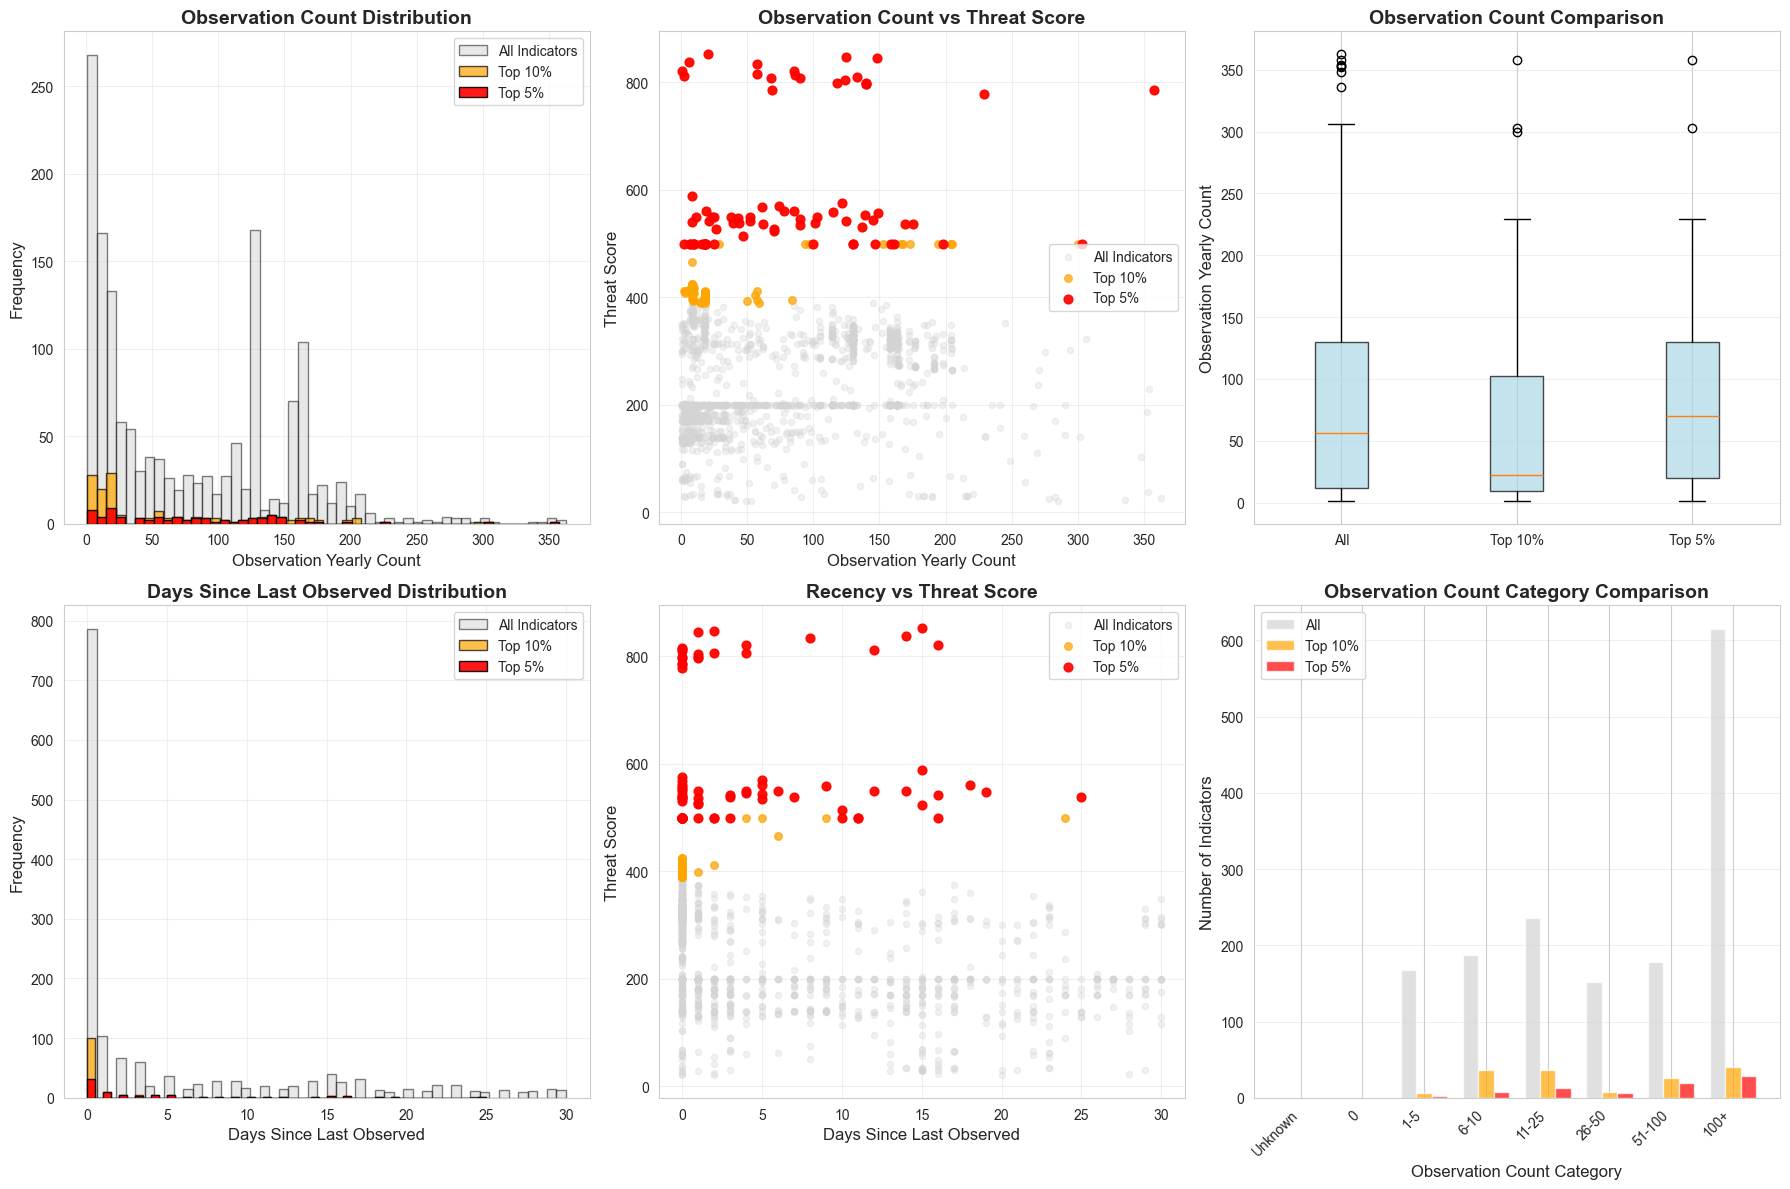


5. Summary of Common Observation Patterns:

Observation Count Pattern:
  - All Indicators Median: 56.00
  - Top 10% Median: 22.00 (Lower than overall)
  - Top 5% Median: 70.00 (Higher than overall)

Recency Pattern:
  - All Indicators Median Days Since Observed: 0.00
  - Top 10% Median Days: 0.00 (Less Recent)
  - Top 5% Median Days: 1.00 (Less Recent)


In [49]:
# Observation Pattern Analysis for Top 5% and Top 10% Indicators
print("=" * 60)
print("OBSERVATION PATTERN ANALYSIS FOR TOP INDICATORS")
print("=" * 60)

# Check available observation-related columns
obs_columns = [col for col in df.columns if 'observation' in col.lower() or 'observed' in col.lower() or 'count' in col.lower()]
print(f"\n1. Available Observation-Related Columns:")
print("-" * 60)
for col in obs_columns:
    print(f"  - {col}")

# Observation Yearly Count Analysis
if 'Observation Yearly Count' in df.columns:
    print(f"\n2. Observation Yearly Count Analysis:")
    print("=" * 60)
    
    # Statistics for all indicators
    print(f"\n2a. Overall Statistics (All Indicators):")
    print("-" * 60)
    print(f"Mean Observation Count: {df['Observation Yearly Count'].mean():.2f}")
    print(f"Median Observation Count: {df['Observation Yearly Count'].median():.2f}")
    print(f"Std Deviation: {df['Observation Yearly Count'].std():.2f}")
    print(f"Min: {df['Observation Yearly Count'].min():.2f}")
    print(f"Max: {df['Observation Yearly Count'].max():.2f}")
    
    # Statistics for top 10%
    print(f"\n2b. Top 10% Indicators - Observation Count Statistics:")
    print("-" * 60)
    top_10_obs = top_10_percent['Observation Yearly Count']
    print(f"Mean Observation Count: {top_10_obs.mean():.2f}")
    print(f"Median Observation Count: {top_10_obs.median():.2f}")
    print(f"Std Deviation: {top_10_obs.std():.2f}")
    print(f"Min: {top_10_obs.min():.2f}")
    print(f"Max: {top_10_obs.max():.2f}")
    
    # Statistics for top 5%
    print(f"\n2c. Top 5% Indicators - Observation Count Statistics:")
    print("-" * 60)
    top_5_obs = top_5_percent['Observation Yearly Count']
    print(f"Mean Observation Count: {top_5_obs.mean():.2f}")
    print(f"Median Observation Count: {top_5_obs.median():.2f}")
    print(f"Std Deviation: {top_5_obs.std():.2f}")
    print(f"Min: {top_5_obs.min():.2f}")
    print(f"Max: {top_5_obs.max():.2f}")
    
    # Correlation between observation count and threat score
    print(f"\n2d. Correlation Analysis:")
    print("-" * 60)
    corr_all = df['Observation Yearly Count'].corr(df['Threat Score'])
    corr_top10 = top_10_percent['Observation Yearly Count'].corr(top_10_percent['Threat Score'])
    corr_top5 = top_5_percent['Observation Yearly Count'].corr(top_5_percent['Threat Score'])
    print(f"Correlation (All Indicators): {corr_all:.3f}")
    print(f"Correlation (Top 10%): {corr_top10:.3f}")
    print(f"Correlation (Top 5%): {corr_top5:.3f}")

# Last Observed Analysis
if 'Last Observed' in df.columns:
    print(f"\n3. Last Observed Date Analysis:")
    print("=" * 60)
    
    # Calculate days since last observed (if conversion succeeded)
    if 'Last Observed' in df.columns:
        try:
            # Check if already datetime, if not convert
            if df['Last Observed'].dtype != 'datetime64[ns]':
                df['Last Observed'] = pd.to_datetime(df['Last Observed'], errors='coerce')
                top_10_percent['Last Observed'] = pd.to_datetime(top_10_percent['Last Observed'], errors='coerce')
                top_5_percent['Last Observed'] = pd.to_datetime(top_5_percent['Last Observed'], errors='coerce')
            
            today = pd.Timestamp.now()
            df['Days_Since_Observed'] = (today - df['Last Observed']).dt.days
            top_10_percent['Days_Since_Observed'] = (today - top_10_percent['Last Observed']).dt.days
            top_5_percent['Days_Since_Observed'] = (today - top_5_percent['Last Observed']).dt.days
            
            print(f"\n3a. Days Since Last Observed - All Indicators:")
            print("-" * 60)
            print(f"Mean: {df['Days_Since_Observed'].mean():.2f} days")
            print(f"Median: {df['Days_Since_Observed'].median():.2f} days")
            print(f"Min: {df['Days_Since_Observed'].min():.2f} days")
            print(f"Max: {df['Days_Since_Observed'].max():.2f} days")
            
            print(f"\n3b. Days Since Last Observed - Top 10%:")
            print("-" * 60)
            print(f"Mean: {top_10_percent['Days_Since_Observed'].mean():.2f} days")
            print(f"Median: {top_10_percent['Days_Since_Observed'].median():.2f} days")
            print(f"Min: {top_10_percent['Days_Since_Observed'].min():.2f} days")
            print(f"Max: {top_10_percent['Days_Since_Observed'].max():.2f} days")
            
            print(f"\n3c. Days Since Last Observed - Top 5%:")
            print("-" * 60)
            print(f"Mean: {top_5_percent['Days_Since_Observed'].mean():.2f} days")
            print(f"Median: {top_5_percent['Days_Since_Observed'].median():.2f} days")
            print(f"Min: {top_5_percent['Days_Since_Observed'].min():.2f} days")
            print(f"Max: {top_5_percent['Days_Since_Observed'].max():.2f} days")
            
            # Recent observation patterns
            print(f"\n3d. Recent Observation Patterns (Last 30/60/90 days):")
            print("-" * 60)
            recent_30_all = (df['Days_Since_Observed'] <= 30).sum()
            recent_60_all = (df['Days_Since_Observed'] <= 60).sum()
            recent_90_all = (df['Days_Since_Observed'] <= 90).sum()
            
            recent_30_top10 = (top_10_percent['Days_Since_Observed'] <= 30).sum()
            recent_60_top10 = (top_10_percent['Days_Since_Observed'] <= 60).sum()
            recent_90_top10 = (top_10_percent['Days_Since_Observed'] <= 90).sum()
            
            recent_30_top5 = (top_5_percent['Days_Since_Observed'] <= 30).sum()
            recent_60_top5 = (top_5_percent['Days_Since_Observed'] <= 60).sum()
            recent_90_top5 = (top_5_percent['Days_Since_Observed'] <= 90).sum()
            
            print(f"All Indicators - Observed in last 30 days: {recent_30_all} ({recent_30_all/len(df)*100:.2f}%)")
            print(f"All Indicators - Observed in last 60 days: {recent_60_all} ({recent_60_all/len(df)*100:.2f}%)")
            print(f"All Indicators - Observed in last 90 days: {recent_90_all} ({recent_90_all/len(df)*100:.2f}%)")
            print(f"\nTop 10% - Observed in last 30 days: {recent_30_top10} ({recent_30_top10/len(top_10_percent)*100:.2f}%)")
            print(f"Top 10% - Observed in last 60 days: {recent_60_top10} ({recent_60_top10/len(top_10_percent)*100:.2f}%)")
            print(f"Top 10% - Observed in last 90 days: {recent_90_top10} ({recent_90_top10/len(top_10_percent)*100:.2f}%)")
            print(f"\nTop 5% - Observed in last 30 days: {recent_30_top5} ({recent_30_top5/len(top_5_percent)*100:.2f}%)")
            print(f"Top 5% - Observed in last 60 days: {recent_60_top5} ({recent_60_top5/len(top_5_percent)*100:.2f}%)")
            print(f"Top 5% - Observed in last 90 days: {recent_90_top5} ({recent_90_top5/len(top_5_percent)*100:.2f}%)")
        except Exception as e:
            print(f"Error processing date information: {e}")

# Observation Count Distribution Analysis
if 'Observation Yearly Count' in df.columns:
    print(f"\n4. Observation Count Distribution Patterns:")
    print("=" * 60)
    
    # Categorize observation counts
    def categorize_obs_count(count):
        if pd.isna(count):
            return 'Unknown'
        elif count == 0:
            return '0'
        elif count <= 5:
            return '1-5'
        elif count <= 10:
            return '6-10'
        elif count <= 25:
            return '11-25'
        elif count <= 50:
            return '26-50'
        elif count <= 100:
            return '51-100'
        else:
            return '100+'
    
    df['Obs_Category'] = df['Observation Yearly Count'].apply(categorize_obs_count)
    top_10_percent['Obs_Category'] = top_10_percent['Observation Yearly Count'].apply(categorize_obs_count)
    top_5_percent['Obs_Category'] = top_5_percent['Observation Yearly Count'].apply(categorize_obs_count)
    
    print(f"\n4a. Observation Count Categories - All Indicators:")
    print("-" * 60)
    obs_cat_all = df['Obs_Category'].value_counts().sort_index()
    for cat, count in obs_cat_all.items():
        print(f"{cat}: {count} indicators ({count/len(df)*100:.2f}%)")
    
    print(f"\n4b. Observation Count Categories - Top 10%:")
    print("-" * 60)
    obs_cat_top10 = top_10_percent['Obs_Category'].value_counts().sort_index()
    for cat, count in obs_cat_top10.items():
        print(f"{cat}: {count} indicators ({count/len(top_10_percent)*100:.2f}%)")
    
    print(f"\n4c. Observation Count Categories - Top 5%:")
    print("-" * 60)
    obs_cat_top5 = top_5_percent['Obs_Category'].value_counts().sort_index()
    for cat, count in obs_cat_top5.items():
        print(f"{cat}: {count} indicators ({count/len(top_5_percent)*100:.2f}%)")

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Observation Count Distribution - All vs Top 10% vs Top 5%
if 'Observation Yearly Count' in df.columns:
    axes[0, 0].hist(df['Observation Yearly Count'], bins=50, alpha=0.5, color='lightgray', label='All Indicators', edgecolor='black')
    axes[0, 0].hist(top_10_percent['Observation Yearly Count'], bins=50, alpha=0.7, color='orange', label='Top 10%', edgecolor='black')
    axes[0, 0].hist(top_5_percent['Observation Yearly Count'], bins=50, alpha=0.9, color='red', label='Top 5%', edgecolor='black')
    axes[0, 0].set_xlabel('Observation Yearly Count', fontsize=12)
    axes[0, 0].set_ylabel('Frequency', fontsize=12)
    axes[0, 0].set_title('Observation Count Distribution', fontsize=14, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Scatter: Observation Count vs Threat Score
    axes[0, 1].scatter(df['Observation Yearly Count'], df['Threat Score'], alpha=0.3, color='lightgray', s=20, label='All Indicators')
    axes[0, 1].scatter(top_10_percent['Observation Yearly Count'], top_10_percent['Threat Score'], alpha=0.7, color='orange', s=30, label='Top 10%')
    axes[0, 1].scatter(top_5_percent['Observation Yearly Count'], top_5_percent['Threat Score'], alpha=0.9, color='red', s=40, label='Top 5%')
    axes[0, 1].set_xlabel('Observation Yearly Count', fontsize=12)
    axes[0, 1].set_ylabel('Threat Score', fontsize=12)
    axes[0, 1].set_title('Observation Count vs Threat Score', fontsize=14, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Box plot: Observation Count by Group
    obs_data = [
        df['Observation Yearly Count'].dropna(),
        top_10_percent['Observation Yearly Count'].dropna(),
        top_5_percent['Observation Yearly Count'].dropna()
    ]
    axes[0, 2].boxplot(obs_data, labels=['All', 'Top 10%', 'Top 5%'], patch_artist=True,
                       boxprops=dict(facecolor='lightblue', alpha=0.7))
    axes[0, 2].set_ylabel('Observation Yearly Count', fontsize=12)
    axes[0, 2].set_title('Observation Count Comparison', fontsize=14, fontweight='bold')
    axes[0, 2].grid(True, alpha=0.3, axis='y')

# 4. Days Since Last Observed (if available)
if 'Last Observed' in df.columns and 'Days_Since_Observed' in df.columns:
    axes[1, 0].hist(df['Days_Since_Observed'].dropna(), bins=50, alpha=0.5, color='lightgray', label='All Indicators', edgecolor='black')
    axes[1, 0].hist(top_10_percent['Days_Since_Observed'].dropna(), bins=50, alpha=0.7, color='orange', label='Top 10%', edgecolor='black')
    axes[1, 0].hist(top_5_percent['Days_Since_Observed'].dropna(), bins=50, alpha=0.9, color='red', label='Top 5%', edgecolor='black')
    axes[1, 0].set_xlabel('Days Since Last Observed', fontsize=12)
    axes[1, 0].set_ylabel('Frequency', fontsize=12)
    axes[1, 0].set_title('Days Since Last Observed Distribution', fontsize=14, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # 5. Scatter: Days Since Observed vs Threat Score
    axes[1, 1].scatter(df['Days_Since_Observed'], df['Threat Score'], alpha=0.3, color='lightgray', s=20, label='All Indicators')
    axes[1, 1].scatter(top_10_percent['Days_Since_Observed'], top_10_percent['Threat Score'], alpha=0.7, color='orange', s=30, label='Top 10%')
    axes[1, 1].scatter(top_5_percent['Days_Since_Observed'], top_5_percent['Threat Score'], alpha=0.9, color='red', s=40, label='Top 5%')
    axes[1, 1].set_xlabel('Days Since Last Observed', fontsize=12)
    axes[1, 1].set_ylabel('Threat Score', fontsize=12)
    axes[1, 1].set_title('Recency vs Threat Score', fontsize=14, fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

# 6. Observation Category Comparison
if 'Obs_Category' in df.columns:
    cat_order = ['Unknown', '0', '1-5', '6-10', '11-25', '26-50', '51-100', '100+']
    cat_all = df['Obs_Category'].value_counts().reindex(cat_order, fill_value=0)
    cat_top10 = top_10_percent['Obs_Category'].value_counts().reindex(cat_order, fill_value=0)
    cat_top5 = top_5_percent['Obs_Category'].value_counts().reindex(cat_order, fill_value=0)
    
    x = np.arange(len(cat_order))
    width = 0.25
    axes[1, 2].bar(x - width, cat_all.values, width, label='All', color='lightgray', alpha=0.7)
    axes[1, 2].bar(x, cat_top10.values, width, label='Top 10%', color='orange', alpha=0.7)
    axes[1, 2].bar(x + width, cat_top5.values, width, label='Top 5%', color='red', alpha=0.7)
    axes[1, 2].set_xlabel('Observation Count Category', fontsize=12)
    axes[1, 2].set_ylabel('Number of Indicators', fontsize=12)
    axes[1, 2].set_title('Observation Count Category Comparison', fontsize=14, fontweight='bold')
    axes[1, 2].set_xticks(x)
    axes[1, 2].set_xticklabels(cat_order, rotation=45, ha='right')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary of Common Patterns
print(f"\n5. Summary of Common Observation Patterns:")
print("=" * 60)
if 'Observation Yearly Count' in df.columns:
    top10_median_obs = top_10_percent['Observation Yearly Count'].median()
    top5_median_obs = top_5_percent['Observation Yearly Count'].median()
    all_median_obs = df['Observation Yearly Count'].median()
    
    print(f"\nObservation Count Pattern:")
    print(f"  - All Indicators Median: {all_median_obs:.2f}")
    print(f"  - Top 10% Median: {top10_median_obs:.2f} ({'Higher' if top10_median_obs > all_median_obs else 'Lower'} than overall)")
    print(f"  - Top 5% Median: {top5_median_obs:.2f} ({'Higher' if top5_median_obs > all_median_obs else 'Lower'} than overall)")

if 'Days_Since_Observed' in df.columns:
    top10_median_days = top_10_percent['Days_Since_Observed'].median()
    top5_median_days = top_5_percent['Days_Since_Observed'].median()
    all_median_days = df['Days_Since_Observed'].median()
    
    print(f"\nRecency Pattern:")
    print(f"  - All Indicators Median Days Since Observed: {all_median_days:.2f}")
    print(f"  - Top 10% Median Days: {top10_median_days:.2f} ({'More Recent' if top10_median_days < all_median_days else 'Less Recent'})")
    print(f"  - Top 5% Median Days: {top5_median_days:.2f} ({'More Recent' if top5_median_days < all_median_days else 'Less Recent'})")


MULTIPLE PARTNERS ANALYSIS

1. Partner Count Statistics:

1a. All Indicators - Partner Count:
------------------------------------------------------------
Mean Number of Partners: 4.84
Median Number of Partners: 4.00
Std Deviation: 3.52
Min: 1
Max: 10

1b. Top 10% Indicators - Partner Count:
------------------------------------------------------------
Mean Number of Partners: 4.64
Median Number of Partners: 5.00
Std Deviation: 2.19
Min: 1
Max: 10

1c. Top 5% Indicators - Partner Count:
------------------------------------------------------------
Mean Number of Partners: 3.81
Median Number of Partners: 4.00
Std Deviation: 2.22
Min: 1
Max: 10

2. Partner Count Distribution:

2a. All Indicators - Partner Count Distribution:
------------------------------------------------------------
1 partner(s): 439 indicators (28.60%)
2 partner(s): 208 indicators (13.55%)
3 partner(s): 71 indicators (4.63%)
4 partner(s): 77 indicators (5.02%)
5 partner(s): 99 indicators (6.45%)
6 partner(s): 65 indicat

C:\Users\jaskew\AppData\Local\Temp\ipykernel_20396\3866736827.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_10_percent['Partner_Count'] = top_10_percent['Partners'].apply(count_partners)
C:\Users\jaskew\AppData\Local\Temp\ipykernel_20396\3866736827.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_5_percent['Partner_Count'] = top_5_percent['Partners'].apply(count_partners)
C:\Users\jaskew\AppData\Local\Temp\ipykernel_20396\3866736827.py:177: MatplotlibDeprecationWarning: The 'labels' param

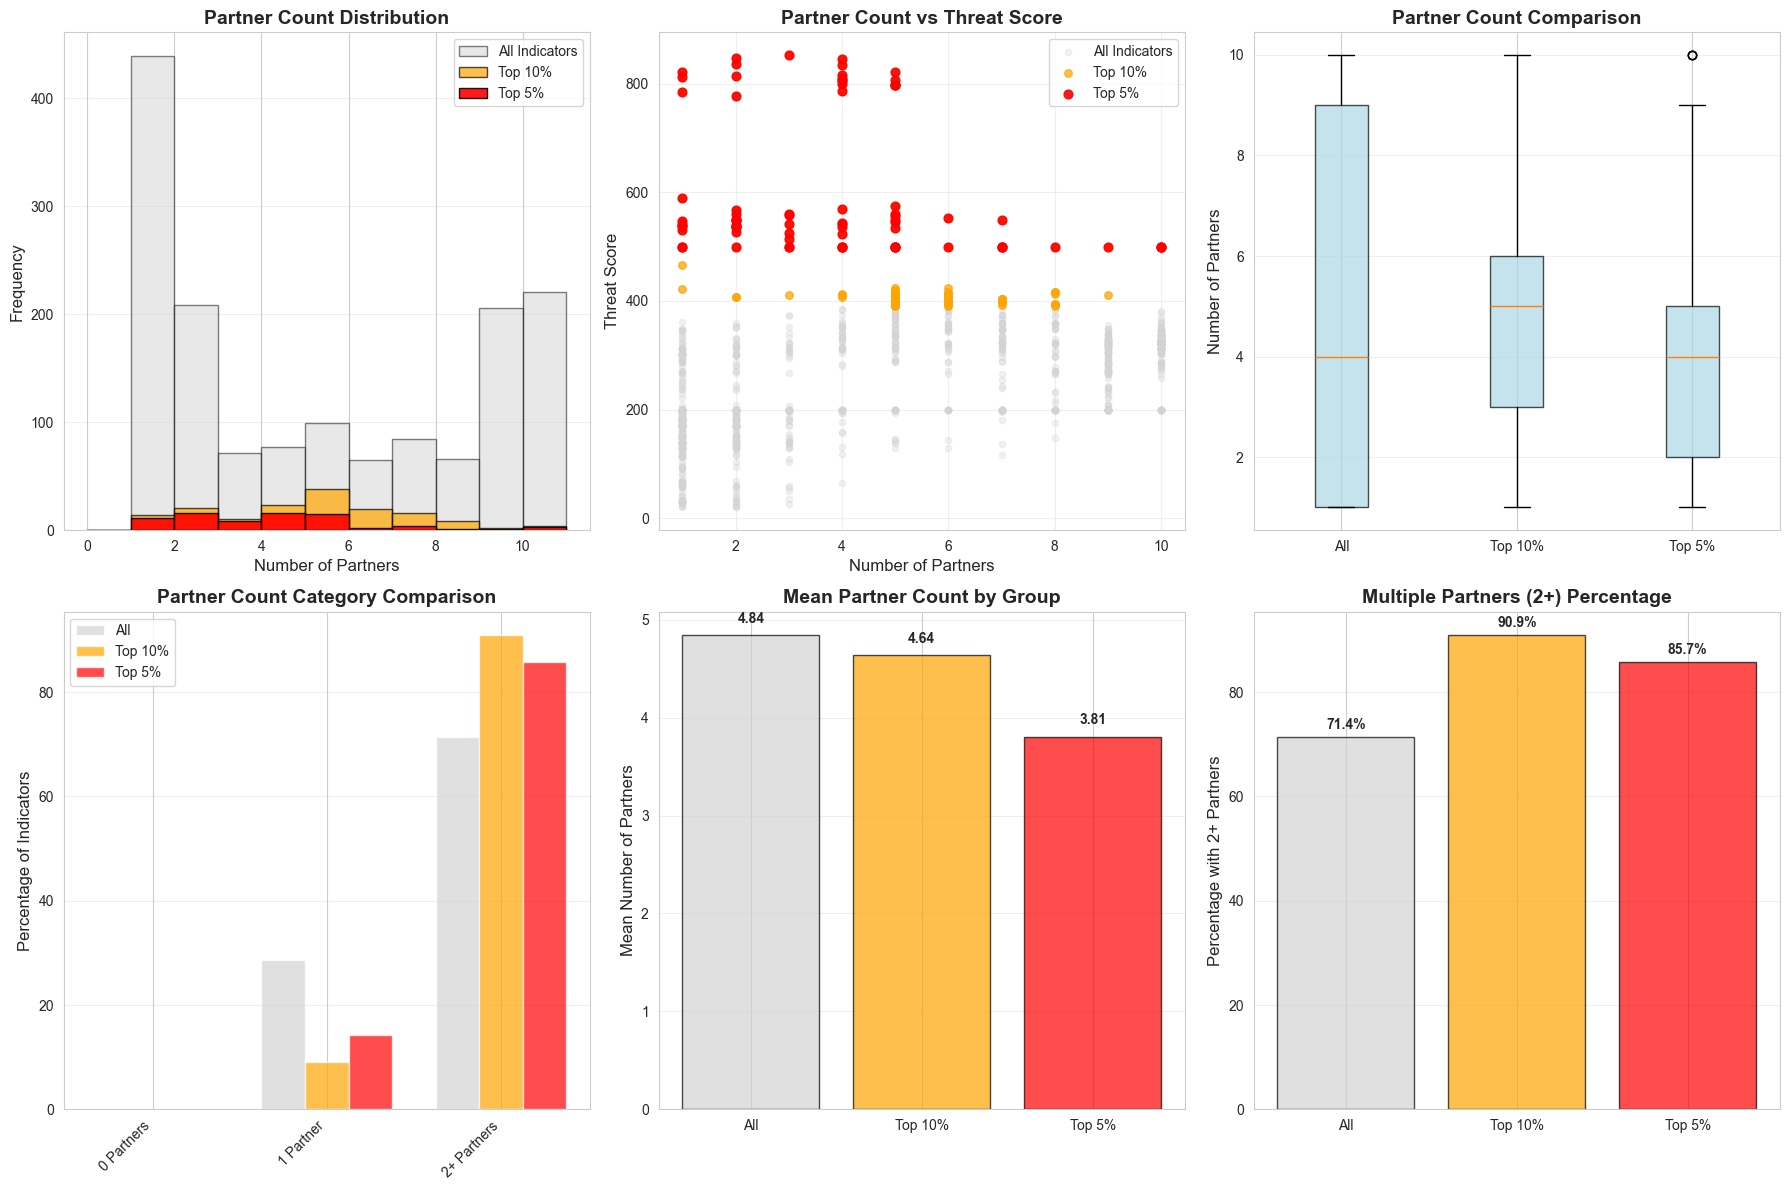


5. Summary:
✗ Top 10% indicators have FEWER partners on average (4.64 vs 4.84)
✗ Top 5% indicators have FEWER partners on average (3.81 vs 4.84)
✓ Top 10% indicators are MORE likely to have 2+ partners (90.91% vs 71.40%)
✓ Top 5% indicators are MORE likely to have 2+ partners (85.71% vs 71.40%)


In [50]:
# Multiple Partners Analysis for Top 5% and Top 10% Indicators
print("=" * 60)
print("MULTIPLE PARTNERS ANALYSIS")
print("=" * 60)

# Function to count number of partners
def count_partners(partner_string):
    if pd.isna(partner_string) or partner_string == '' or str(partner_string).strip() == '':
        return 0
    # Split by comma and count non-empty partners
    partners = str(partner_string).split(',')
    return len([p for p in partners if p.strip() != ''])

# Count partners for all indicators
df['Partner_Count'] = df['Partners'].apply(count_partners)
top_10_percent['Partner_Count'] = top_10_percent['Partners'].apply(count_partners)
top_5_percent['Partner_Count'] = top_5_percent['Partners'].apply(count_partners)

print(f"\n1. Partner Count Statistics:")
print("=" * 60)

print(f"\n1a. All Indicators - Partner Count:")
print("-" * 60)
print(f"Mean Number of Partners: {df['Partner_Count'].mean():.2f}")
print(f"Median Number of Partners: {df['Partner_Count'].median():.2f}")
print(f"Std Deviation: {df['Partner_Count'].std():.2f}")
print(f"Min: {df['Partner_Count'].min()}")
print(f"Max: {df['Partner_Count'].max()}")

print(f"\n1b. Top 10% Indicators - Partner Count:")
print("-" * 60)
print(f"Mean Number of Partners: {top_10_percent['Partner_Count'].mean():.2f}")
print(f"Median Number of Partners: {top_10_percent['Partner_Count'].median():.2f}")
print(f"Std Deviation: {top_10_percent['Partner_Count'].std():.2f}")
print(f"Min: {top_10_percent['Partner_Count'].min()}")
print(f"Max: {top_10_percent['Partner_Count'].max()}")

print(f"\n1c. Top 5% Indicators - Partner Count:")
print("-" * 60)
print(f"Mean Number of Partners: {top_5_percent['Partner_Count'].mean():.2f}")
print(f"Median Number of Partners: {top_5_percent['Partner_Count'].median():.2f}")
print(f"Std Deviation: {top_5_percent['Partner_Count'].std():.2f}")
print(f"Min: {top_5_percent['Partner_Count'].min()}")
print(f"Max: {top_5_percent['Partner_Count'].max()}")

# Distribution of partner counts
print(f"\n2. Partner Count Distribution:")
print("=" * 60)

print(f"\n2a. All Indicators - Partner Count Distribution:")
print("-" * 60)
partner_dist_all = df['Partner_Count'].value_counts().sort_index()
for count, num_indicators in partner_dist_all.items():
    percentage = (num_indicators / len(df)) * 100
    print(f"{int(count)} partner(s): {num_indicators} indicators ({percentage:.2f}%)")

print(f"\n2b. Top 10% Indicators - Partner Count Distribution:")
print("-" * 60)
partner_dist_top10 = top_10_percent['Partner_Count'].value_counts().sort_index()
for count, num_indicators in partner_dist_top10.items():
    percentage = (num_indicators / len(top_10_percent)) * 100
    print(f"{int(count)} partner(s): {num_indicators} indicators ({percentage:.2f}%)")

print(f"\n2c. Top 5% Indicators - Partner Count Distribution:")
print("-" * 60)
partner_dist_top5 = top_5_percent['Partner_Count'].value_counts().sort_index()
for count, num_indicators in partner_dist_top5.items():
    percentage = (num_indicators / len(top_5_percent)) * 100
    print(f"{int(count)} partner(s): {num_indicators} indicators ({percentage:.2f}%)")

# Multiple partners analysis (2+ partners)
print(f"\n3. Multiple Partners (2+ Partners) Analysis:")
print("=" * 60)

multiple_all = (df['Partner_Count'] >= 2).sum()
multiple_top10 = (top_10_percent['Partner_Count'] >= 2).sum()
multiple_top5 = (top_5_percent['Partner_Count'] >= 2).sum()

single_all = (df['Partner_Count'] == 1).sum()
single_top10 = (top_10_percent['Partner_Count'] == 1).sum()
single_top5 = (top_5_percent['Partner_Count'] == 1).sum()

none_all = (df['Partner_Count'] == 0).sum()
none_top10 = (top_10_percent['Partner_Count'] == 0).sum()
none_top5 = (top_5_percent['Partner_Count'] == 0).sum()

print(f"\n3a. All Indicators:")
print("-" * 60)
print(f"0 partners: {none_all} ({none_all/len(df)*100:.2f}%)")
print(f"1 partner: {single_all} ({single_all/len(df)*100:.2f}%)")
print(f"2+ partners: {multiple_all} ({multiple_all/len(df)*100:.2f}%)")

print(f"\n3b. Top 10% Indicators:")
print("-" * 60)
print(f"0 partners: {none_top10} ({none_top10/len(top_10_percent)*100:.2f}%)")
print(f"1 partner: {single_top10} ({single_top10/len(top_10_percent)*100:.2f}%)")
print(f"2+ partners: {multiple_top10} ({multiple_top10/len(top_10_percent)*100:.2f}%)")

print(f"\n3c. Top 5% Indicators:")
print("-" * 60)
print(f"0 partners: {none_top5} ({none_top5/len(top_5_percent)*100:.2f}%)")
print(f"1 partner: {single_top5} ({single_top5/len(top_5_percent)*100:.2f}%)")
print(f"2+ partners: {multiple_top5} ({multiple_top5/len(top_5_percent)*100:.2f}%)")

# Statistical comparison
print(f"\n4. Statistical Comparison:")
print("=" * 60)
mean_all = df['Partner_Count'].mean()
mean_top10 = top_10_percent['Partner_Count'].mean()
mean_top5 = top_5_percent['Partner_Count'].mean()

pct_diff_top10 = ((mean_top10 - mean_all) / mean_all * 100) if mean_all > 0 else 0
pct_diff_top5 = ((mean_top5 - mean_all) / mean_all * 100) if mean_all > 0 else 0

print(f"\n4a. Mean Partner Count Comparison:")
print("-" * 60)
print(f"All Indicators: {mean_all:.2f}")
print(f"Top 10%: {mean_top10:.2f} ({'+' if pct_diff_top10 > 0 else ''}{pct_diff_top10:.2f}% difference)")
print(f"Top 5%: {mean_top5:.2f} ({'+' if pct_diff_top5 > 0 else ''}{pct_diff_top5:.2f}% difference)")

# Multiple partners percentage
pct_multiple_all = (multiple_all / len(df)) * 100
pct_multiple_top10 = (multiple_top10 / len(top_10_percent)) * 100
pct_multiple_top5 = (multiple_top5 / len(top_5_percent)) * 100

print(f"\n4b. Percentage with 2+ Partners:")
print("-" * 60)
print(f"All Indicators: {pct_multiple_all:.2f}%")
print(f"Top 10%: {pct_multiple_top10:.2f}% ({'+' if pct_multiple_top10 > pct_multiple_all else ''}{pct_multiple_top10 - pct_multiple_all:.2f} percentage points)")
print(f"Top 5%: {pct_multiple_top5:.2f}% ({'+' if pct_multiple_top5 > pct_multiple_all else ''}{pct_multiple_top5 - pct_multiple_all:.2f} percentage points)")

# Correlation between partner count and threat score
corr_partner_score = df['Partner_Count'].corr(df['Threat Score'])
corr_partner_score_top10 = top_10_percent['Partner_Count'].corr(top_10_percent['Threat Score'])
corr_partner_score_top5 = top_5_percent['Partner_Count'].corr(top_5_percent['Threat Score'])

print(f"\n4c. Correlation: Partner Count vs Threat Score:")
print("-" * 60)
print(f"All Indicators: {corr_partner_score:.3f}")
print(f"Top 10%: {corr_partner_score_top10:.3f}")
print(f"Top 5%: {corr_partner_score_top5:.3f}")

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Partner Count Distribution - Histogram
axes[0, 0].hist(df['Partner_Count'], bins=range(0, int(df['Partner_Count'].max())+2), alpha=0.5, 
                color='lightgray', label='All Indicators', edgecolor='black')
axes[0, 0].hist(top_10_percent['Partner_Count'], bins=range(0, int(df['Partner_Count'].max())+2), alpha=0.7, 
                color='orange', label='Top 10%', edgecolor='black')
axes[0, 0].hist(top_5_percent['Partner_Count'], bins=range(0, int(df['Partner_Count'].max())+2), alpha=0.9, 
                color='red', label='Top 5%', edgecolor='black')
axes[0, 0].set_xlabel('Number of Partners', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Partner Count Distribution', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Scatter: Partner Count vs Threat Score
axes[0, 1].scatter(df['Partner_Count'], df['Threat Score'], alpha=0.3, color='lightgray', s=20, label='All Indicators')
axes[0, 1].scatter(top_10_percent['Partner_Count'], top_10_percent['Threat Score'], alpha=0.7, 
                   color='orange', s=30, label='Top 10%')
axes[0, 1].scatter(top_5_percent['Partner_Count'], top_5_percent['Threat Score'], alpha=0.9, 
                   color='red', s=40, label='Top 5%')
axes[0, 1].set_xlabel('Number of Partners', fontsize=12)
axes[0, 1].set_ylabel('Threat Score', fontsize=12)
axes[0, 1].set_title('Partner Count vs Threat Score', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Box Plot: Partner Count by Group
partner_data = [
    df['Partner_Count'],
    top_10_percent['Partner_Count'],
    top_5_percent['Partner_Count']
]
axes[0, 2].boxplot(partner_data, labels=['All', 'Top 10%', 'Top 5%'], patch_artist=True,
                   boxprops=dict(facecolor='lightblue', alpha=0.7))
axes[0, 2].set_ylabel('Number of Partners', fontsize=12)
axes[0, 2].set_title('Partner Count Comparison', fontsize=14, fontweight='bold')
axes[0, 2].grid(True, alpha=0.3, axis='y')

# 4. Multiple Partners (2+) Comparison
categories = ['0 Partners', '1 Partner', '2+ Partners']
all_values = [none_all/len(df)*100, single_all/len(df)*100, multiple_all/len(df)*100]
top10_values = [none_top10/len(top_10_percent)*100, single_top10/len(top_10_percent)*100, multiple_top10/len(top_10_percent)*100]
top5_values = [none_top5/len(top_5_percent)*100, single_top5/len(top_5_percent)*100, multiple_top5/len(top_5_percent)*100]

x = np.arange(len(categories))
width = 0.25
axes[1, 0].bar(x - width, all_values, width, label='All', color='lightgray', alpha=0.7)
axes[1, 0].bar(x, top10_values, width, label='Top 10%', color='orange', alpha=0.7)
axes[1, 0].bar(x + width, top5_values, width, label='Top 5%', color='red', alpha=0.7)
axes[1, 0].set_ylabel('Percentage of Indicators', fontsize=12)
axes[1, 0].set_title('Partner Count Category Comparison', fontsize=14, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(categories, rotation=45, ha='right')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 5. Mean Partner Count Comparison
means = [mean_all, mean_top10, mean_top5]
colors = ['lightgray', 'orange', 'red']
axes[1, 1].bar(['All', 'Top 10%', 'Top 5%'], means, color=colors, alpha=0.7, edgecolor='black')
axes[1, 1].set_ylabel('Mean Number of Partners', fontsize=12)
axes[1, 1].set_title('Mean Partner Count by Group', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')
# Add value labels on bars
for i, v in enumerate(means):
    axes[1, 1].text(i, v + 0.1, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

# 6. Percentage with 2+ Partners
pct_multiple = [pct_multiple_all, pct_multiple_top10, pct_multiple_top5]
axes[1, 2].bar(['All', 'Top 10%', 'Top 5%'], pct_multiple, color=colors, alpha=0.7, edgecolor='black')
axes[1, 2].set_ylabel('Percentage with 2+ Partners', fontsize=12)
axes[1, 2].set_title('Multiple Partners (2+) Percentage', fontsize=14, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3, axis='y')
# Add value labels on bars
for i, v in enumerate(pct_multiple):
    axes[1, 2].text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Summary
print(f"\n5. Summary:")
print("=" * 60)
if mean_top10 > mean_all:
    print(f"✓ Top 10% indicators have MORE partners on average ({mean_top10:.2f} vs {mean_all:.2f})")
else:
    print(f"✗ Top 10% indicators have FEWER partners on average ({mean_top10:.2f} vs {mean_all:.2f})")

if mean_top5 > mean_all:
    print(f"✓ Top 5% indicators have MORE partners on average ({mean_top5:.2f} vs {mean_all:.2f})")
else:
    print(f"✗ Top 5% indicators have FEWER partners on average ({mean_top5:.2f} vs {mean_all:.2f})")

if pct_multiple_top10 > pct_multiple_all:
    print(f"✓ Top 10% indicators are MORE likely to have 2+ partners ({pct_multiple_top10:.2f}% vs {pct_multiple_all:.2f}%)")
else:
    print(f"✗ Top 10% indicators are LESS likely to have 2+ partners ({pct_multiple_top10:.2f}% vs {pct_multiple_all:.2f}%)")

if pct_multiple_top5 > pct_multiple_all:
    print(f"✓ Top 5% indicators are MORE likely to have 2+ partners ({pct_multiple_top5:.2f}% vs {pct_multiple_all:.2f}%)")
else:
    print(f"✗ Top 5% indicators are LESS likely to have 2+ partners ({pct_multiple_top5:.2f}% vs {pct_multiple_all:.2f}%)")


THREAT ASSESSMENT DATA REPORT
Data analysis output directory: C:\Users\jaskew\Documents\project_repository\notebooks\ThreatAssessment Scoring\DataReports

KEY METRICS SUMMARY
Total Indicators: 1,535
Median Threat Score: 240
Top 10% Threshold: 390
Top 5% Threshold: 499
Top 10% Count: 154
Top 5% Count: 77
Average Partners: 4.8
Multiple Partner %: 71.4%
Median Observations/Year: 56

THREAT SCORE DISTRIBUTION


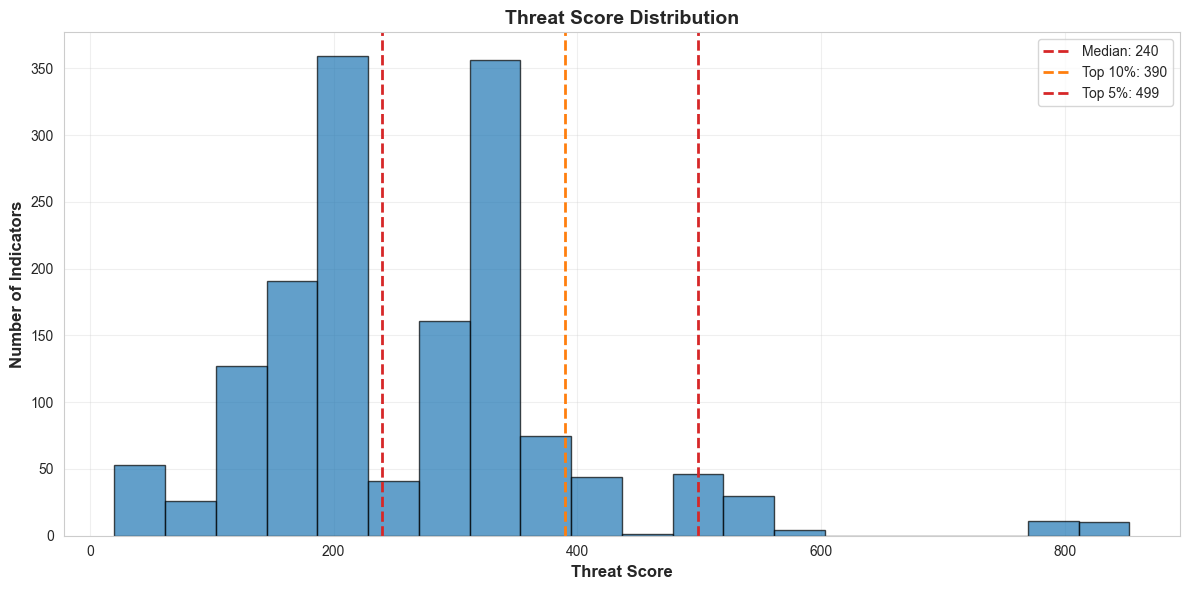


SCORE COMPARISON BY GROUP


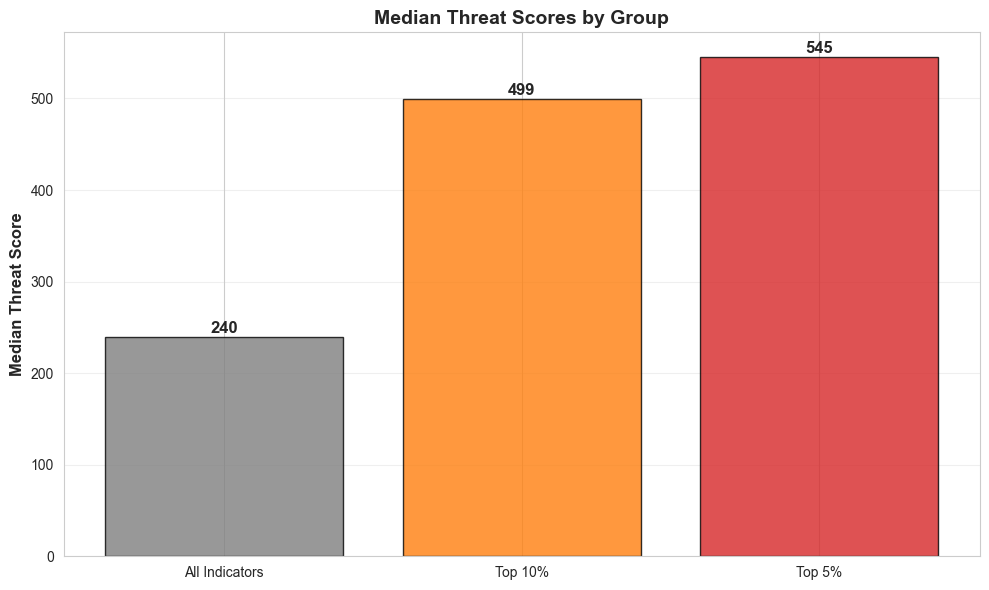


PARTNER ANALYSIS
Avg Partners (All): 4.8
Avg Partners (Top 10%): 4.6
Avg Partners (Top 5%): 3.8
Single Partner %: 28.6%
Multiple Partners %: 71.4%
Zero Partners %: 0.0%

PARTNER COUNT DISTRIBUTION


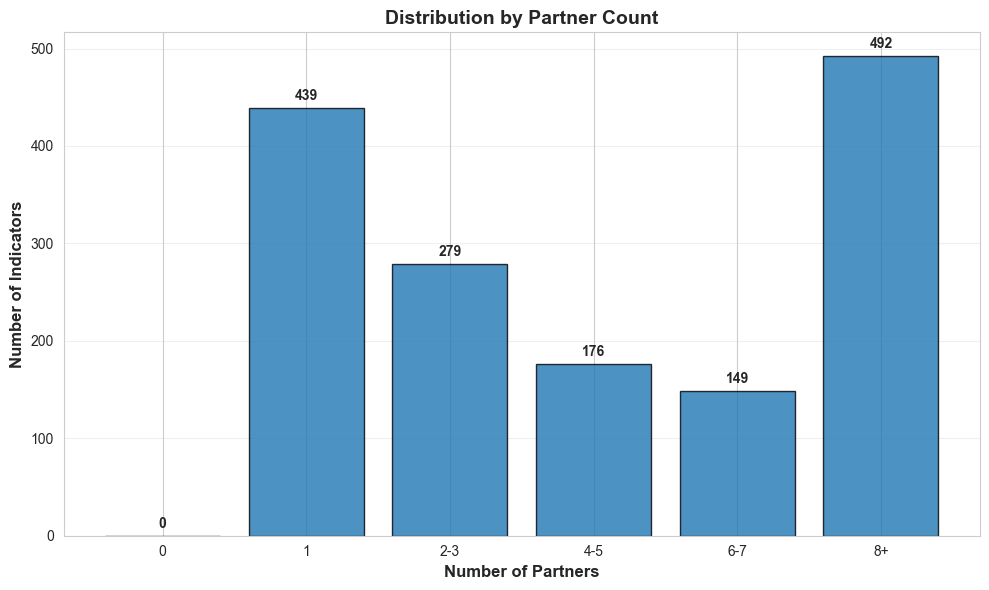


RECENT ACTIVITY
Recent 30 Days (All): 1,535
Recent 30 Days (Top 10%): 154
Recent 30 Days (Top 5%): 77
Recent 60 Days (All): 1,535
Recent 90 Days (All): 1,535

OBSERVATION FREQUENCY
Median Obs/Year (All): 56
Median Obs/Year (Top 10%): 22
Median Obs/Year (Top 5%): 70
Max Observations: 363
Min Observations: 1

Observation Frequency by Group:


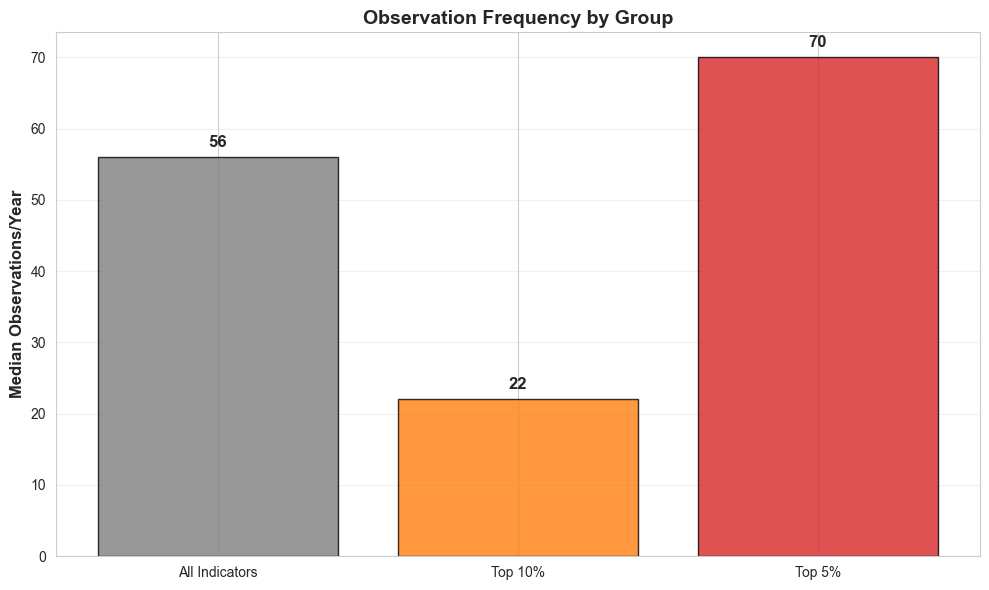


TOP PARTNER ORGANIZATIONS


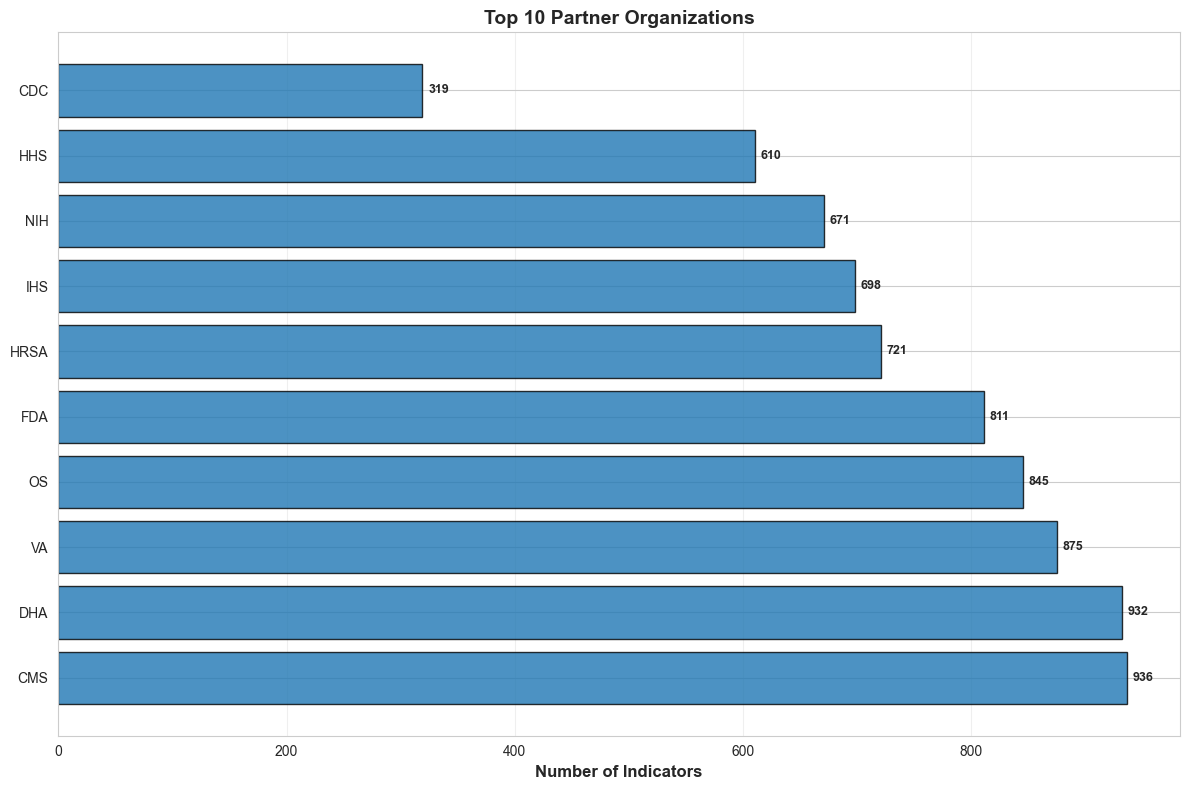


STATISTICAL SUMMARY
Mean Score: 262.9
Std Deviation: 125.6
Min Score: 20
Max Score: 853
25th Percentile: 181
75th Percentile: 329
Skewness: 1.30

THREAT ASSESSMENT DATA REPORT COMPLETED

Report Contents:
   • Key Metrics Summary
   • Threat Score Distribution Chart
   • Score Comparison by Group Chart
   • Partner Analysis Metrics
   • Partner Count Distribution Chart
   • Recent Activity Metrics
   • Observation Frequency Metrics
   • Observation Frequency Chart
   • Top Partner Organizations Chart
   • Statistical Summary

Data analysis complete with charts and key metrics
Charts displayed inline with clear titles and value labels
All metrics calculated and presented in structured format


In [51]:
# Threat Assessment Data Report
import os
print("=" * 80)
print("THREAT ASSESSMENT DATA REPORT")
print("=" * 80)

# Define HHS_COLORS used for plotting and data visualization
# Colors are hex strings compatible with matplotlib
HHS_COLORS = {
    'blue': '#1f77b4',
    'red': '#d62728',
    'orange': '#ff7f0e',
    'gray': '#7f7f7f'
}

# Define output directory for any data exports
output_dir = r"C:\Users\jaskew\Documents\project_repository\notebooks\ThreatAssessment Scoring\DataReports"
os.makedirs(output_dir, exist_ok=True)

print(f"Data analysis output directory: {output_dir}")

# Compute observation medians (safe - only if the column exists)
if 'Observation Yearly Count' in df.columns:
    obs_median_all = df['Observation Yearly Count'].median()
    obs_median_top10 = (top_10_percent['Observation Yearly Count'].median()
                        if 'top_10_percent' in globals() and 'Observation Yearly Count' in top_10_percent.columns
                        else float('nan'))
    obs_median_top5 = (top_5_percent['Observation Yearly Count'].median()
                       if 'top_5_percent' in globals() and 'Observation Yearly Count' in top_5_percent.columns
                       else float('nan'))

# Ensure median_score is defined
if 'Threat Score' in df.columns:
    median_score = df['Threat Score'].median()
elif 'ThreatConnect Threat Score' in df.columns:
    median_score = df['ThreatConnect Threat Score'].median()
else:
    median_score = 0

# ============================================================================
# KEY METRICS SUMMARY
# ============================================================================
print("\n" + "="*80)
print("KEY METRICS SUMMARY")
print("="*80)

# Ensure partner-related summary variables exist
if 'Partner_Count' in df.columns:
    mean_partners_all = df['Partner_Count'].mean()
    mean_partners_top10 = (top_10_percent['Partner_Count'].mean()
                           if 'top_10_percent' in globals() and 'Partner_Count' in top_10_percent.columns
                           else float('nan'))
    mean_partners_top5 = (top_5_percent['Partner_Count'].mean()
                          if 'top_5_percent' in globals() and 'Partner_Count' in top_5_percent.columns
                          else float('nan'))
    single_all = int((df['Partner_Count'] == 1).sum())
    none_all = int((df['Partner_Count'] == 0).sum())
    pct_multiple_all = ((df['Partner_Count'] > 1).sum() / len(df) * 100) if len(df) > 0 else 0.0
else:
    # Try to infer counts from the 'Partners' text column (comma-separated)
    try:
        def _count_partners_from_str(s):
            if pd.isna(s) or str(s).strip() == "":
                return 0
            return len([p for p in str(s).split(',') if p.strip() != ""])
        if 'Partners' in df.columns:
            df['Partner_Count'] = df['Partners'].apply(_count_partners_from_str)
            mean_partners_all = df['Partner_Count'].mean()
            mean_partners_top10 = (top_10_percent['Partners'].apply(_count_partners_from_str).mean()
                                   if 'top_10_percent' in globals() and 'Partners' in top_10_percent.columns
                                   else float('nan'))
            mean_partners_top5 = (top_5_percent['Partners'].apply(_count_partners_from_str).mean()
                                  if 'top_5_percent' in globals() and 'Partners' in top_5_percent.columns
                                  else float('nan'))
            single_all = int((df['Partner_Count'] == 1).sum())
            none_all = int((df['Partner_Count'] == 0).sum())
            pct_multiple_all = ((df['Partner_Count'] > 1).sum() / len(df) * 100) if len(df) > 0 else 0.0
        else:
            mean_partners_all = mean_partners_top10 = mean_partners_top5 = float('nan')
            single_all = none_all = 0
            pct_multiple_all = 0.0
    except Exception:
        mean_partners_all = mean_partners_top10 = mean_partners_top5 = float('nan')
        single_all = none_all = 0
        pct_multiple_all = 0.0

# Display Key Metrics
print(f"Total Indicators: {len(df):,}")
print(f"Median Threat Score: {median_score:.0f}")
print(f"Top 10% Threshold: {score_threshold_10:.0f}")
print(f"Top 5% Threshold: {score_threshold_5:.0f}")
print(f"Top 10% Count: {top_10_percent_count:,}")
print(f"Top 5% Count: {top_5_percent_count:,}")
print(f"Average Partners: {mean_partners_all:.1f}")
print(f"Multiple Partner %: {pct_multiple_all:.1f}%")

if 'Observation Yearly Count' in df.columns:
    print(f"Median Observations/Year: {obs_median_all:.0f}")

# ============================================================================
# THREAT SCORE DISTRIBUTION CHART
# ============================================================================
print("\n" + "="*80)
print("THREAT SCORE DISTRIBUTION")
print("="*80)

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(df['Threat Score'], bins=20, alpha=0.7, color=HHS_COLORS['blue'], edgecolor='black')
ax.axvline(median_score, color=HHS_COLORS['red'], linestyle='--', linewidth=2, 
           label=f'Median: {median_score:.0f}')
ax.axvline(score_threshold_10, color=HHS_COLORS['orange'], linestyle='--', linewidth=2,
           label=f'Top 10%: {score_threshold_10:.0f}')
ax.axvline(score_threshold_5, color=HHS_COLORS['red'], linestyle='--', linewidth=2,
           label=f'Top 5%: {score_threshold_5:.0f}')

ax.set_xlabel('Threat Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Indicators', fontsize=12, fontweight='bold')
ax.set_title('Threat Score Distribution', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================================
# SCORE COMPARISON BY GROUP CHART
# ============================================================================
print("\n" + "="*80)
print("SCORE COMPARISON BY GROUP")
print("="*80)

fig, ax = plt.subplots(figsize=(10, 6))
categories = ['All Indicators', 'Top 10%', 'Top 5%']
median_values = [df['Threat Score'].median(), 
                top_10_percent['Threat Score'].median(),
                top_5_percent['Threat Score'].median()]
colors_comp = [HHS_COLORS['gray'], HHS_COLORS['orange'], HHS_COLORS['red']]

bars = ax.bar(categories, median_values, color=colors_comp, alpha=0.8, edgecolor='black')
ax.set_ylabel('Median Threat Score', fontsize=12, fontweight='bold')
ax.set_title('Median Threat Scores by Group', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars, median_values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.0f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# ============================================================================
# PARTNER ANALYSIS METRICS
# ============================================================================
print("\n" + "="*80)
print("PARTNER ANALYSIS")
print("="*80)

print(f"Avg Partners (All): {mean_partners_all:.1f}")
print(f"Avg Partners (Top 10%): {mean_partners_top10:.1f}")
print(f"Avg Partners (Top 5%): {mean_partners_top5:.1f}")
print(f"Single Partner %: {(single_all/len(df)*100):.1f}%")
print(f"Multiple Partners %: {pct_multiple_all:.1f}%")
print(f"Zero Partners %: {(none_all/len(df)*100):.1f}%")

# ============================================================================
# PARTNER COUNT DISTRIBUTION CHART
# ============================================================================
print("\n" + "="*80)
print("PARTNER COUNT DISTRIBUTION")
print("="*80)

fig, ax = plt.subplots(figsize=(10, 6))

# Create partner count categories
def categorize_partners(count):
    if count == 0: return '0'
    elif count == 1: return '1'
    elif count <= 3: return '2-3'
    elif count <= 5: return '4-5'
    elif count <= 7: return '6-7'
    else: return '8+'

df['Partner_Category'] = df['Partner_Count'].apply(categorize_partners)
cat_order = ['0', '1', '2-3', '4-5', '6-7', '8+']
cat_counts = df['Partner_Category'].value_counts().reindex(cat_order, fill_value=0)

bars = ax.bar(cat_order, cat_counts.values, color=HHS_COLORS['blue'], alpha=0.8, edgecolor='black')
ax.set_xlabel('Number of Partners', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Indicators', fontsize=12, fontweight='bold')
ax.set_title('Distribution by Partner Count', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars, cat_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 5, f'{val}', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# Clean up temporary column
df.drop('Partner_Category', axis=1, inplace=True)

# ============================================================================
# RECENT ACTIVITY METRICS
# ============================================================================
print("\n" + "="*80)
print("RECENT ACTIVITY")
print("="*80)

print(f"Recent 30 Days (All): {recent_30_all:,}")
print(f"Recent 30 Days (Top 10%): {recent_30_top10:,}")
print(f"Recent 30 Days (Top 5%): {recent_30_top5:,}")
print(f"Recent 60 Days (All): {recent_60_all:,}")
print(f"Recent 90 Days (All): {recent_90_all:,}")

# ============================================================================
# OBSERVATION FREQUENCY (if available)
# ============================================================================
if 'Observation Yearly Count' in df.columns:
    print("\n" + "="*80)
    print("OBSERVATION FREQUENCY")
    print("="*80)
    
    print(f"Median Obs/Year (All): {obs_median_all:.0f}")
    print(f"Median Obs/Year (Top 10%): {obs_median_top10:.0f}")
    print(f"Median Obs/Year (Top 5%): {obs_median_top5:.0f}")
    print(f"Max Observations: {df['Observation Yearly Count'].max():.0f}")
    print(f"Min Observations: {df['Observation Yearly Count'].min():.0f}")
    
    # Observation frequency chart
    print("\nObservation Frequency by Group:")
    
    fig, ax = plt.subplots(figsize=(10, 6))
    obs_categories = ['All Indicators', 'Top 10%', 'Top 5%']
    obs_values = [obs_median_all, obs_median_top10, obs_median_top5]
    
    bars = ax.bar(obs_categories, obs_values, color=colors_comp, alpha=0.8, edgecolor='black')
    ax.set_ylabel('Median Observations/Year', fontsize=12, fontweight='bold')
    ax.set_title('Observation Frequency by Group', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    for bar, val in zip(bars, obs_values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.0f}', 
                 ha='center', va='bottom', fontweight='bold', fontsize=12)
    
    plt.tight_layout()
    plt.show()

# ============================================================================
# TOP PARTNERS CHART (if available)
# ============================================================================
if len(overall_partner_counts) > 0:
    print("\n" + "="*80)
    print("TOP PARTNER ORGANIZATIONS")
    print("="*80)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    top_10_partners = overall_partner_counts.head(10)
    
    bars = ax.barh(range(len(top_10_partners)), top_10_partners.values, 
                   color=HHS_COLORS['blue'], alpha=0.8, edgecolor='black')
    ax.set_yticks(range(len(top_10_partners)))
    ax.set_yticklabels(top_10_partners.index, fontsize=10)
    ax.set_xlabel('Number of Indicators', fontsize=12, fontweight='bold')
    ax.set_title('Top 10 Partner Organizations', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, top_10_partners.values)):
        ax.text(val + 5, bar.get_y() + bar.get_height()/2, f'{val}', 
                 ha='left', va='center', fontweight='bold', fontsize=9)
    
    plt.tight_layout()
    plt.show()

# ============================================================================
# STATISTICAL SUMMARY
# ============================================================================
print("\n" + "="*80)
print("STATISTICAL SUMMARY")
print("="*80)

print(f"Mean Score: {df['Threat Score'].mean():.1f}")
print(f"Std Deviation: {df['Threat Score'].std():.1f}")
print(f"Min Score: {df['Threat Score'].min():.0f}")
print(f"Max Score: {df['Threat Score'].max():.0f}")
print(f"25th Percentile: {df['Threat Score'].quantile(0.25):.0f}")
print(f"75th Percentile: {df['Threat Score'].quantile(0.75):.0f}")
print(f"Skewness: {df['Threat Score'].skew():.2f}")

# ============================================================================
# REPORT COMPLETION
# ============================================================================
print(f"\n{'='*80}")
print(f"THREAT ASSESSMENT DATA REPORT COMPLETED")
print(f"{'='*80}")

print("\nReport Contents:")
print("   • Key Metrics Summary")
print("   • Threat Score Distribution Chart")
print("   • Score Comparison by Group Chart") 
print("   • Partner Analysis Metrics")
print("   • Partner Count Distribution Chart")
print("   • Recent Activity Metrics")

if 'Observation Yearly Count' in df.columns:
    print("   • Observation Frequency Metrics")
    print("   • Observation Frequency Chart")

if len(overall_partner_counts) > 0:
    print("   • Top Partner Organizations Chart")

print("   • Statistical Summary")

print(f"\nData analysis complete with charts and key metrics")
print(f"Charts displayed inline with clear titles and value labels")
print(f"All metrics calculated and presented in structured format")
print(f"{'='*80}")

In [52]:
# ================================================================================
# COMPREHENSIVE EXCEL DATA EXPORT
# ================================================================================
import pandas as pd
import os
from datetime import datetime
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Border, Side, Alignment

print("=" * 80)
print("GENERATING COMPREHENSIVE EXCEL DATA EXPORT")
print("=" * 80)

# Create output directory
output_dir = r'C:\Users\jaskew\Documents\project_repository\notebooks\ThreatAssessment Scoring\DataReports'
os.makedirs(output_dir, exist_ok=True)

# Generate timestamp
excel_timestamp = datetime.now().strftime("%Y%m%d_%H%M")
excel_filename = f'ThreatAssessment_DataExport_{excel_timestamp}.xlsx'
file_path = os.path.join(output_dir, excel_filename)

print(f"Creating comprehensive Excel export: {file_path}")
print(f"Output directory: {output_dir}")

# Create Excel workbook with multiple worksheets
wb = Workbook()

# Define styling elements
title_font = Font(name='Segoe UI', size=14, bold=True, color='FFFFFF')
header_font = Font(name='Segoe UI', size=12, bold=True, color='FFFFFF')
data_font = Font(name='Segoe UI', size=10)
title_fill = PatternFill(start_color='2F5597', end_color='2F5597', fill_type='solid')
header_fill = PatternFill(start_color='4472C4', end_color='4472C4', fill_type='solid')
border = Border(left=Side(style='thin'), right=Side(style='thin'), 
                top=Side(style='thin'), bottom=Side(style='thin'))

# ================================================================================
# WORKSHEET 1: EXECUTIVE SUMMARY
# ================================================================================
ws1 = wb.active
ws1.title = "Executive Summary"

# Executive Summary Data
executive_summary = {
    'Metric': [
        'Total Indicators (Last 30 Days)',
        'Average Threat Score',
        'Median Threat Score', 
        'Highest Threat Score',
        'Top 10% Threshold Score',
        'Top 5% Threshold Score',
        'Indicators in Top 10%',
        'Indicators in Top 5%',
        'Most Active Partner',
        'Partner Organizations Count',
        'Most Recent Observation',
        'Average Days Since Last Observed'
    ],
    'Value': [
        len(df),
        f"{df['Threat Score'].mean():.2f}",
        f"{df['Threat Score'].median():.2f}",
        f"{df['Threat Score'].max():.2f}",
        f"{score_threshold_10:.2f}",
        f"{score_threshold_5:.2f}",
        top_10_percent_count,
        top_5_percent_count,
        df['Partners'].value_counts().index[0] if 'Partners' in df.columns else 'N/A',
        len(df['Partners'].unique()) if 'Partners' in df.columns else 'N/A',
        df['Last Observed'].max().strftime('%Y-%m-%d') if len(df) > 0 else 'N/A',
        f"{df['Days_Since_Observed'].mean():.1f} days" if 'Days_Since_Observed' in df.columns else 'N/A'
    ]
}

# Add title
ws1['A1'] = 'THREAT ASSESSMENT - EXECUTIVE SUMMARY'
ws1['A1'].font = title_font
ws1['A1'].fill = title_fill
ws1.merge_cells('A1:B1')

# Add headers
ws1['A3'] = 'Metric'
ws1['B3'] = 'Value'
for cell in ['A3', 'B3']:
    ws1[cell].font = header_font
    ws1[cell].fill = header_fill
    ws1[cell].border = border

# Add data
for i, (metric, value) in enumerate(zip(executive_summary['Metric'], executive_summary['Value']), 4):
    ws1[f'A{i}'] = metric
    ws1[f'B{i}'] = value
    for cell in [f'A{i}', f'B{i}']:
        ws1[cell].font = data_font
        ws1[cell].border = border

# Set column widths
ws1.column_dimensions['A'].width = 35
ws1.column_dimensions['B'].width = 25

# ================================================================================
# WORKSHEET 2: THREAT SCORE ANALYSIS
# ================================================================================
ws2 = wb.create_sheet(title="Threat Score Analysis")

# Score distribution data - Updated to use new scoring ranges
score_ranges = ['low', 'medium', 'high', 'critical']
score_bins = [0, 200, 500, 800, 1001]
score_counts = []

for i, range_label in enumerate(score_ranges):
    if i == 0:  # low: 0-199
        count = len(df[(df['Threat Score'] >= score_bins[i]) & (df['Threat Score'] < score_bins[i+1])])
    elif i == len(score_ranges) - 1:  # critical: 800-1001
        count = len(df[(df['Threat Score'] >= score_bins[i]) & (df['Threat Score'] <= score_bins[i+1])])
    else:  # medium: 200-499, high: 500-799
        count = len(df[(df['Threat Score'] >= score_bins[i]) & (df['Threat Score'] < score_bins[i+1])])
    score_counts.append(count)

# Add title
ws2['A1'] = 'THREAT SCORE DISTRIBUTION ANALYSIS'
ws2['A1'].font = title_font
ws2['A1'].fill = title_fill
ws2.merge_cells('A1:C1')

# Headers
headers = ['Score Range', 'Count', 'Percentage']
for i, header in enumerate(headers, 1):
    cell = ws2.cell(row=3, column=i, value=header)
    cell.font = header_font
    cell.fill = header_fill
    cell.border = border

# Add data
total_indicators = len(df)
for i, (range_val, count) in enumerate(zip(score_ranges, score_counts), 4):
    percentage = (count / total_indicators * 100) if total_indicators > 0 else 0
    # Create descriptive range labels
    if i == 4:  # low
        range_display = f"{range_val} (0-199)"
    elif i == 5:  # medium
        range_display = f"{range_val} (200-499)" 
    elif i == 6:  # high
        range_display = f"{range_val} (500-799)"
    else:  # critical
        range_display = f"{range_val} (800-1001)"
    
    ws2[f'A{i}'] = range_display
    ws2[f'B{i}'] = count
    ws2[f'C{i}'] = f"{percentage:.1f}%"
    for col in ['A', 'B', 'C']:
        ws2[f'{col}{i}'].font = data_font
        ws2[f'{col}{i}'].border = border

# Set column widths
ws2.column_dimensions['A'].width = 20
ws2.column_dimensions['B'].width = 10
ws2.column_dimensions['C'].width = 15

# ================================================================================
# SCORE COMPARISON ANALYSIS SECTION
# ================================================================================
# Check for score comparison data and add it to the worksheet
print("Checking for score comparison data...")

# Check if score_comparison_df exists in the current namespace
score_comparison_available = False
score_comp_df = None

# Try to get the score_comparison_df from globals
if 'score_comparison_df' in globals():
    score_comp_df = globals()['score_comparison_df']
    print(f"Found score_comparison_df in globals")
    if score_comp_df is not None:
        print(f"Score comparison DataFrame is not None")
        print(f"Shape: {score_comp_df.shape}")
        print(f"Columns: {score_comp_df.columns.tolist()}")
        if isinstance(score_comp_df, pd.DataFrame) and not score_comp_df.empty:
            score_comparison_available = True
            print("Score comparison data is available for Excel export")
        else:
            print("Score comparison DataFrame is empty or not a DataFrame")
    else:
        print("score_comparison_df is None")
else:
    print("score_comparison_df not found in globals")

if score_comparison_available and score_comp_df is not None:
    try:
        # Add section separator
        ws2['A11'] = 'SCORE COMPARISON ANALYSIS: THREATCONNECT vs CURRENT'
        ws2['A11'].font = title_font
        ws2['A11'].fill = title_fill
        ws2.merge_cells('A11:E11')
        
        # Determine which columns to use based on what's available
        tc_score_col = None
        current_score_col = None
        diff_col = None
        
        # Look for ThreatConnect score column
        possible_tc_cols = ['ThreatConnect Threat Score', 'TC Score', 'ThreatConnect Score']
        for col in possible_tc_cols:
            if col in score_comp_df.columns:
                tc_score_col = col
                break
        
        # Look for current score column  
        possible_current_cols = ['Threat Score', 'Current Score', 'New Score']
        for col in possible_current_cols:
            if col in score_comp_df.columns:
                current_score_col = col
                break
        
        # Look for difference column
        possible_diff_cols = ['Difference', 'Diff', 'Score Difference']
        for col in possible_diff_cols:
            if col in score_comp_df.columns:
                diff_col = col
                break
        
        print(f"Using columns: TC={tc_score_col}, Current={current_score_col}, Diff={diff_col}")
        
        # If we have the necessary columns, create the comparison analysis
        if tc_score_col and current_score_col:
            # Calculate difference if not available
            if not diff_col and tc_score_col and current_score_col:
                score_comp_df['Calculated_Difference'] = score_comp_df[current_score_col] - score_comp_df[tc_score_col]
                diff_col = 'Calculated_Difference'
                print("Calculated difference column")
            
            # Create summary metrics
            score_comp_summary = {
                'Metric': [
                    'Total Indicators Compared',
                    f'Average {tc_score_col}',
                    f'Average {current_score_col}',
                    'Average Score Difference',
                    'Median Score Difference',
                    'Indicators with Improved Scores',
                    'Indicators with Degraded Scores', 
                    'Indicators with Unchanged Scores'
                ],
                'Value': [
                    len(score_comp_df),
                    f"{score_comp_df[tc_score_col].mean():.2f}",
                    f"{score_comp_df[current_score_col].mean():.2f}",
                    f"{score_comp_df[diff_col].mean():.2f}" if diff_col else "N/A",
                    f"{score_comp_df[diff_col].median():.2f}" if diff_col else "N/A",
                    len(score_comp_df[score_comp_df[diff_col] > 0]) if diff_col else "N/A",
                    len(score_comp_df[score_comp_df[diff_col] < 0]) if diff_col else "N/A",
                    len(score_comp_df[score_comp_df[diff_col] == 0]) if diff_col else "N/A"
                ]
            }
            
            # Add comparison headers
            ws2['A13'] = 'Comparison Metric'
            ws2['B13'] = 'Value'
            for cell in ['A13', 'B13']:
                ws2[cell].font = header_font
                ws2[cell].fill = header_fill
                ws2[cell].border = border

            # Add comparison data
            for i, (metric, value) in enumerate(zip(score_comp_summary['Metric'], score_comp_summary['Value']), 14):
                ws2[f'A{i}'] = metric
                ws2[f'B{i}'] = value
                for cell in [f'A{i}', f'B{i}']:
                    ws2[cell].font = data_font
                    ws2[cell].border = border
            
            print("Successfully added score comparison analysis to Excel export")
            
            # Add TOP 20 LARGEST SCORE DIFFERENCES section
            print("Adding top 20 largest score differences...")
            
            # Get top 20 by absolute difference
            score_comp_df_sorted = score_comp_df.copy()
            score_comp_df_sorted['Abs_Difference'] = score_comp_df_sorted[diff_col].abs()
            top_20_diffs = score_comp_df_sorted.nlargest(20, 'Abs_Difference')
            
            # Add section title
            start_row = 23  # Start after previous data
            ws2[f'A{start_row}'] = 'TOP 20 LARGEST SCORE DIFFERENCES'
            ws2[f'A{start_row}'].font = title_font
            ws2[f'A{start_row}'].fill = title_fill
            ws2.merge_cells(f'A{start_row}:E{start_row}')
            
            # Add headers for top 20 differences
            headers_top20 = ['Rank', 'Indicator', 'ThreatConnect Score', 'Current Score', 'Difference']
            for i, header in enumerate(headers_top20, 1):
                col_letter = chr(64 + i)
                cell = ws2[f'{col_letter}{start_row + 2}']
                cell.value = header
                cell.font = header_font
                cell.fill = header_fill
                cell.border = border
            
            # Add top 20 data
            indicator_col = 'Indicator'
            for rank, (_, row) in enumerate(top_20_diffs.iterrows(), 1):
                row_num = start_row + 2 + rank
                ws2[f'A{row_num}'] = rank
                ws2[f'B{row_num}'] = row.get(indicator_col, 'N/A') if indicator_col in row.index else 'N/A'
                ws2[f'C{row_num}'] = row[tc_score_col] if tc_score_col in row.index else 'N/A'
                ws2[f'D{row_num}'] = row[current_score_col] if current_score_col in row.index else 'N/A'
                ws2[f'E{row_num}'] = row[diff_col] if diff_col in row.index else 'N/A'
                
                for col_letter in ['A', 'B', 'C', 'D', 'E']:
                    cell = ws2[f'{col_letter}{row_num}']
                    cell.font = data_font
                    cell.border = border
                    # Color code the difference column (green for positive, red for negative)
                    if col_letter == 'E' and row[diff_col] > 0:
                        cell.fill = PatternFill(start_color='C6EFCE', end_color='C6EFCE', fill_type='solid')
                    elif col_letter == 'E' and row[diff_col] < 0:
                        cell.fill = PatternFill(start_color='FFC7CE', end_color='FFC7CE', fill_type='solid')
            
            print("Successfully added top 20 largest score differences")
            
        else:
            print(f"Missing required columns for comparison analysis")
            print(f"Available columns: {score_comp_df.columns.tolist()}")
            
            # Add a note about missing data
            ws2['A11'] = 'SCORE COMPARISON DATA AVAILABLE BUT MISSING REQUIRED COLUMNS'
            ws2['A11'].font = title_font
            ws2['A11'].fill = title_fill
            ws2.merge_cells('A11:E11')
            
    except Exception as e:
        print(f"Error adding score comparison analysis: {str(e)}")
        # Add error note
        ws2['A11'] = 'ERROR IN SCORE COMPARISON ANALYSIS - SEE CONSOLE OUTPUT'
        ws2['A11'].font = title_font
        ws2['A11'].fill = title_fill
        ws2.merge_cells('A11:E11')

else:
    print("Score comparison data not available for Excel export")
    # Add note about missing data
    ws2['A11'] = 'SCORE COMPARISON DATA NOT AVAILABLE'
    ws2['A11'].font = title_font
    ws2['A11'].fill = title_fill
    ws2.merge_cells('A11:E11')

# ================================================================================
# WORKSHEET 3: PARTNER ANALYSIS
# ================================================================================
ws3 = wb.create_sheet(title="Partner Analysis")

# Top partners analysis
if 'Partners' in df.columns and len(overall_partner_counts) > 0:
    # Get top 20 partners
    top_20_partners = overall_partner_counts.head(20)
    
    # Create partner data for worksheet
    partner_data = pd.DataFrame({
        'Partner Organization': top_20_partners.index,
        'Indicator Count': top_20_partners.values
    }).reset_index(drop=True)
    
    # Add title
    ws3['A1'] = 'TOP 20 PARTNER ORGANIZATIONS BY INDICATOR COUNT'
    ws3['A1'].font = title_font
    ws3['A1'].fill = title_fill
    ws3.merge_cells('A1:C1')
    
    # Headers
    headers = ['Rank', 'Partner Organization', 'Indicator Count']
    for i, header in enumerate(headers, 1):
        cell = ws3.cell(row=3, column=i, value=header)
        cell.font = header_font
        cell.fill = header_fill
        cell.border = border
    
    # Add data
    for i, (idx, row) in enumerate(partner_data.iterrows(), 4):
        ws3[f'A{i}'] = i - 3  # Rank
        ws3[f'B{i}'] = row['Partner Organization']
        ws3[f'C{i}'] = row['Indicator Count']
        for col in ['A', 'B', 'C']:
            ws3[f'{col}{i}'].font = data_font
            ws3[f'{col}{i}'].border = border
    
    # Set column widths
    ws3.column_dimensions['A'].width = 8
    ws3.column_dimensions['B'].width = 35
    ws3.column_dimensions['C'].width = 15
else:
    ws3['A1'] = 'PARTNER ANALYSIS - NO PARTNER DATA AVAILABLE'
    ws3['A1'].font = title_font
    ws3['A1'].fill = title_fill

# ================================================================================
# WORKSHEET 4: ACTIVITY ANALYSIS
# ================================================================================
ws4 = wb.create_sheet(title="Activity Analysis")

# Recent activity analysis
recent_periods = [
    ('Last 7 Days', 7),
    ('Last 14 Days', 14), 
    ('Last 21 Days', 21),
    ('Last 30 Days', 30)
]

activity_data = []
if 'Days_Since_Observed' in df.columns:
    for period_name, days in recent_periods:
        count = len(df[df['Days_Since_Observed'] <= days])
        avg_score = df[df['Days_Since_Observed'] <= days]['Threat Score'].mean() if count > 0 else 0
        activity_data.append([period_name, count, f"{avg_score:.2f}"])

# Add title
ws4['A1'] = 'RECENT ACTIVITY ANALYSIS'
ws4['A1'].font = title_font
ws4['A1'].fill = title_fill
ws4.merge_cells('A1:C1')

# Headers
headers = ['Time Period', 'Indicator Count', 'Average Threat Score']
for i, header in enumerate(headers, 1):
    cell = ws4.cell(row=3, column=i, value=header)
    cell.font = header_font
    cell.fill = header_fill
    cell.border = border

# Add data
for i, row_data in enumerate(activity_data, 4):
    for j, value in enumerate(row_data, 1):
        cell = ws4.cell(row=i, column=j, value=value)
        cell.font = data_font
        cell.border = border

# Set column widths
ws4.column_dimensions['A'].width = 15
ws4.column_dimensions['B'].width = 15
ws4.column_dimensions['C'].width = 20

# ================================================================================
# WORKSHEET 5: TOP PERFORMERS
# ================================================================================
ws5 = wb.create_sheet(title="Top Performers")

# Top 50 indicators by threat score
top_performers = df.nlargest(50, 'Threat Score').copy()

# Add title
ws5['A1'] = 'TOP 50 INDICATORS BY THREAT SCORE'
ws5['A1'].font = title_font
ws5['A1'].fill = title_fill
ws5.merge_cells('A1:E1')

# Determine available columns for top performers
top_columns = ['Threat Score', 'Last Observed', 'Days_Since_Observed']
if 'Partners' in df.columns:
    top_columns.append('Partners')

headers = ['Rank'] + top_columns
for i, header in enumerate(headers, 1):
    cell = ws5.cell(row=3, column=i, value=header)
    cell.font = header_font
    cell.fill = header_fill
    cell.border = border

# Add data
max_rows = min(50, len(top_performers))
for idx, (_, row) in enumerate(top_performers.head(max_rows).iterrows(), 4):
    ws5[f'A{idx}'] = idx - 3  # Rank
    
    for i, col in enumerate(top_columns, 2):
        if col in row.index:
            value = row[col]
            if col == 'Last Observed' and pd.notna(value):
                value = value.strftime('%Y-%m-%d')
            elif pd.isna(value):
                value = 'N/A'
        else:
            value = 'N/A'
        
        cell = ws5.cell(row=idx, column=i, value=str(value))
        cell.font = data_font
        cell.border = border

# Set column widths
top_column_widths = [8, 15, 15, 18]
if 'Partners' in df.columns:
    top_column_widths.append(30)

for i, width in enumerate(top_column_widths, 1):
    ws5.column_dimensions[chr(64 + i)].width = width

# ================================================================================
# WORKSHEET 6: RAW DATA
# ================================================================================
ws6 = wb.create_sheet(title="Raw Data")

# Add title
ws6['A1'] = 'RAW DATA EXPORT - LAST 30 DAYS'
ws6['A1'].font = title_font
ws6['A1'].fill = title_fill
ws6.merge_cells('A1:F1')

# Determine export columns based on available data
export_columns = ['Threat Score', 'Last Observed', 'Days_Since_Observed']
if 'Partners' in df.columns:
    export_columns.append('Partners')

# Additional columns if available
for col in ['Partner_Count', 'Observation Yearly Count']:
    if col in df.columns:
        export_columns.append(col)

# Add headers
for i, col in enumerate(export_columns, 1):
    cell = ws6.cell(row=3, column=i, value=col)
    cell.font = header_font
    cell.fill = header_fill
    cell.border = border

# Add raw data (limited to reasonable size for Excel)
max_rows = min(10000, len(df))  # Limit to 10,000 rows for performance
for idx, (_, row) in enumerate(df.head(max_rows).iterrows(), 4):
    for i, col in enumerate(export_columns, 1):
        if col in row.index:
            value = row[col]
            if col == 'Last Observed' and pd.notna(value):
                value = value.strftime('%Y-%m-%d')
            elif pd.isna(value):
                value = 'N/A'
        else:
            value = 'N/A'
        
        cell = ws6.cell(row=idx, column=i, value=str(value))
        cell.font = data_font
        cell.border = border

# Set column widths for raw data
raw_column_widths = [15, 15, 18, 30, 15, 20]
for i, width in enumerate(raw_column_widths[:len(export_columns)], 1):
    ws6.column_dimensions[chr(64 + i)].width = width

# ================================================================================
# SAVE WORKBOOK
# ================================================================================
try:
    wb.save(file_path)
    print(f"\n✓ Excel export completed successfully!")
    print(f"  File saved: {excel_filename}")
    print(f"  Location: {output_dir}")
    print(f"  Worksheets created: {len(wb.sheetnames)}")
    print(f"  Worksheet names: {', '.join(wb.sheetnames)}")
    
except Exception as e:
    print(f"\n✗ Error saving Excel file: {str(e)}")
    print(f"  Attempted location: {file_path}")

print("\n" + "=" * 80)
print("EXCEL DATA EXPORT COMPLETE")
print("=" * 80)

GENERATING COMPREHENSIVE EXCEL DATA EXPORT
Creating comprehensive Excel export: C:\Users\jaskew\Documents\project_repository\notebooks\ThreatAssessment Scoring\DataReports\ThreatAssessment_DataExport_20251204_1033.xlsx
Output directory: C:\Users\jaskew\Documents\project_repository\notebooks\ThreatAssessment Scoring\DataReports
Checking for score comparison data...
Found score_comparison_df in globals
Score comparison DataFrame is not None
Shape: (1535, 4)
Columns: ['Indicator', 'ThreatConnect Threat Score', 'Threat Score', 'Difference']
Score comparison data is available for Excel export
Using columns: TC=ThreatConnect Threat Score, Current=Threat Score, Diff=Difference
Successfully added score comparison analysis to Excel export
Adding top 20 largest score differences...
Successfully added top 20 largest score differences

✓ Excel export completed successfully!
  File saved: ThreatAssessment_DataExport_20251204_1033.xlsx
  Location: C:\Users\jaskew\Documents\project_repository\noteboo

In [53]:
# ================================================================================
# SCORE COMPARISON ANALYSIS
# ================================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=" * 80)
print("SCORE COMPARISON ANALYSIS")
print("=" * 80)

# Load the Score Comparison sheet from the Excel file
try:
    file_path_scores = r'Z:\HTOC\Data_Analytics\Data\Threat Assessment Scores\Threat_Assessment_Scores.xlsx'
    score_comparison_df_temp = pd.read_excel(file_path_scores, sheet_name='Score Comparison')
    
    print(f"Score Comparison data loaded successfully!")
    print(f"Shape (before filtering): {score_comparison_df_temp.shape}")
    print(f"Columns: {score_comparison_df_temp.columns.tolist()}")
    
    # Filter to only include indicators from the last 30 days (matching df)
    if 'Indicator' in score_comparison_df_temp.columns and 'Indicator' in df.columns:
        last_30_indicators = set(df['Indicator'].tolist())
        score_comparison_df = score_comparison_df_temp[score_comparison_df_temp['Indicator'].isin(last_30_indicators)].copy()
        
        print(f"\n{'='*60}")
        print("FILTERED TO LAST 30 DAYS INDICATORS")
        print("=" * 60)
        print(f"Original comparison records: {len(score_comparison_df_temp)}")
        print(f"Indicators in last 30 days (df): {len(last_30_indicators)}")
        print(f"Matched comparison records: {len(score_comparison_df)}")
    else:
        score_comparison_df = score_comparison_df_temp.copy()
        print("\nWarning: Could not filter by last 30 days - using all data")
    
    print(f"\nFirst few rows:")
    print(score_comparison_df.head())
    
    # Display basic statistics about the comparison data
    print(f"\n{'='*60}")
    print("SCORE COMPARISON DATA OVERVIEW (LAST 30 DAYS)")
    print("=" * 60)
    
    # Check for any numeric columns that might represent different score versions
    numeric_cols = score_comparison_df.select_dtypes(include=[np.number]).columns.tolist()
    print(f"Numeric columns found: {numeric_cols}")
    
    if len(numeric_cols) >= 2:
        print(f"\nDetailed statistics for numeric columns:")
        for col in numeric_cols:
            print(f"\n{col}:")
            print(f"  Count: {score_comparison_df[col].count()}")
            print(f"  Mean: {score_comparison_df[col].mean():.2f}")
            print(f"  Std: {score_comparison_df[col].std():.2f}")
            print(f"  Min: {score_comparison_df[col].min()}")
            print(f"  Max: {score_comparison_df[col].max()}")
    
except Exception as e:
    print(f"Error loading Score Comparison sheet: {str(e)}")
    print("Please verify:")
    print("1. The file path exists and is accessible")
    print("2. The 'Score Comparison' sheet exists in the Excel file")
    print("3. You have permissions to read the file")
    score_comparison_df = None

SCORE COMPARISON ANALYSIS
Score Comparison data loaded successfully!
Shape (before filtering): (1868, 4)
Columns: ['Indicator', 'ThreatConnect Threat Score', 'Threat Score', 'Difference']

FILTERED TO LAST 30 DAYS INDICATORS
Original comparison records: 1868
Indicators in last 30 days (df): 1535
Matched comparison records: 1535

First few rows:
         Indicator  ThreatConnect Threat Score  Threat Score  Difference
0  1-you.njalla.no                         590           143        -447
1     1.54.101.176                         255           138        -117
2    101.71.130.99                         648           393        -255
3   101.89.174.236                         433           306        -127
4      102.0.5.152                         288           170        -118

SCORE COMPARISON DATA OVERVIEW (LAST 30 DAYS)
Numeric columns found: ['ThreatConnect Threat Score', 'Threat Score', 'Difference']

Detailed statistics for numeric columns:

ThreatConnect Threat Score:
  Count: 1535


COMPREHENSIVE SCORE DIFFERENCE ANALYSIS

1. OVERALL SCORE COMPARISON METRICS:
------------------------------------------------------------
Total Indicators Compared: 1,535
Average ThreatConnect Score: 475.71
Average Current Threat Score: 262.89
Average Score Difference: -212.81
Median Score Difference: -186.00
Score Difference Range: -945 to 560
Score Difference Std Dev: 190.95

2. SCORE CHANGE DIRECTION ANALYSIS:
------------------------------------------------------------
Improved Scores: 121 (7.9%)
Unchanged Scores: 0 (0.0%)
Degraded Scores: 1,414 (92.1%)
Average Improvement (when positive): +117.97
Average Degradation (when negative): -241.12

3. SCORE CHANGE MAGNITUDE ANALYSIS:
------------------------------------------------------------
Large Improvements (≥100 points): 45 (2.9%)
Large Degradations (≤-100 points): 1,225 (79.8%)
Moderate Changes (-100 to +100): 265 (17.3%)

4. SCORE DIFFERENCE DISTRIBUTION:
------------------------------------------------------------


C:\Users\jaskew\AppData\Local\Temp\ipykernel_20396\4045838710.py:141: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(box_data, labels=box_labels, patch_artist=True)


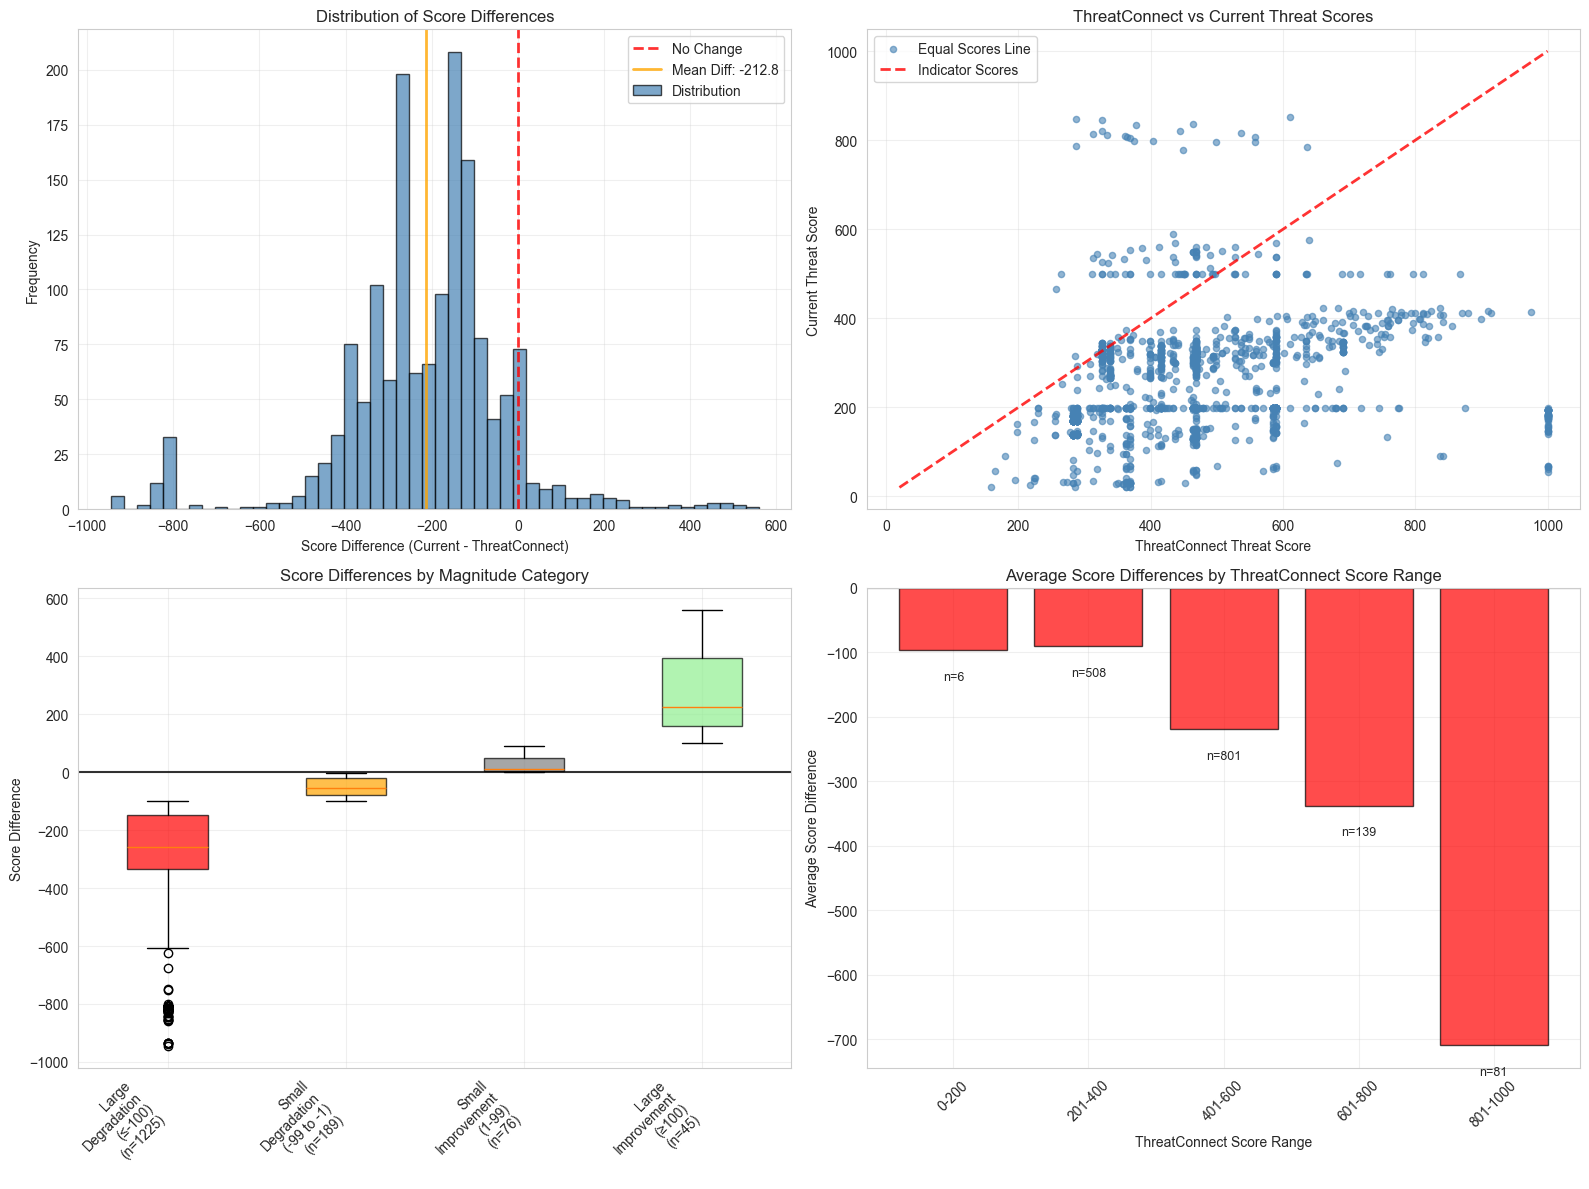


5. KEY INSIGHTS:
------------------------------------------------------------
• Current scores are significantly LOWER than ThreatConnect scores on average
• Majority of indicators show score degradation compared to ThreatConnect
• Significant portion of indicators show large score degradations (>100 points)
• Score variability is HIGH (std dev: 191)

SCORE DIFFERENCE ANALYSIS COMPLETE


In [54]:
# ================================================================================
# SCORE DIFFERENCE METRICS AND ANALYSIS
# ================================================================================

if score_comparison_df is not None:
    print(f"\n{'='*80}")
    print("COMPREHENSIVE SCORE DIFFERENCE ANALYSIS")
    print("=" * 80)
    
    # Calculate detailed metrics about score differences
    score_diff_metrics = {
        'total_indicators': len(score_comparison_df),
        'avg_threatconnect_score': score_comparison_df['ThreatConnect Threat Score'].mean(),
        'avg_current_score': score_comparison_df['Threat Score'].mean(),
        'avg_difference': score_comparison_df['Difference'].mean(),
        'median_difference': score_comparison_df['Difference'].median(),
        'std_difference': score_comparison_df['Difference'].std(),
        'min_difference': score_comparison_df['Difference'].min(),
        'max_difference': score_comparison_df['Difference'].max()
    }
    
    # Score improvement/deterioration analysis
    improved_scores = score_comparison_df[score_comparison_df['Difference'] > 0]
    unchanged_scores = score_comparison_df[score_comparison_df['Difference'] == 0]
    degraded_scores = score_comparison_df[score_comparison_df['Difference'] < 0]
    
    improvement_metrics = {
        'improved_count': len(improved_scores),
        'improved_pct': (len(improved_scores) / len(score_comparison_df)) * 100,
        'unchanged_count': len(unchanged_scores),
        'unchanged_pct': (len(unchanged_scores) / len(score_comparison_df)) * 100,
        'degraded_count': len(degraded_scores),
        'degraded_pct': (len(degraded_scores) / len(score_comparison_df)) * 100,
        'avg_improvement': improved_scores['Difference'].mean() if len(improved_scores) > 0 else 0,
        'avg_degradation': abs(degraded_scores['Difference'].mean()) if len(degraded_scores) > 0 else 0
    }
    
    # Magnitude analysis
    large_improvements = score_comparison_df[score_comparison_df['Difference'] >= 100]
    large_degradations = score_comparison_df[score_comparison_df['Difference'] <= -100]
    moderate_changes = score_comparison_df[(score_comparison_df['Difference'] > -100) & (score_comparison_df['Difference'] < 100)]
    
    magnitude_metrics = {
        'large_improvements': len(large_improvements),
        'large_improvements_pct': (len(large_improvements) / len(score_comparison_df)) * 100,
        'large_degradations': len(large_degradations),
        'large_degradations_pct': (len(large_degradations) / len(score_comparison_df)) * 100,
        'moderate_changes': len(moderate_changes),
        'moderate_changes_pct': (len(moderate_changes) / len(score_comparison_df)) * 100
    }
    
    # Print comprehensive analysis
    print(f"\n1. OVERALL SCORE COMPARISON METRICS:")
    print("-" * 60)
    print(f"Total Indicators Compared: {score_diff_metrics['total_indicators']:,}")
    print(f"Average ThreatConnect Score: {score_diff_metrics['avg_threatconnect_score']:.2f}")
    print(f"Average Current Threat Score: {score_diff_metrics['avg_current_score']:.2f}")
    print(f"Average Score Difference: {score_diff_metrics['avg_difference']:.2f}")
    print(f"Median Score Difference: {score_diff_metrics['median_difference']:.2f}")
    print(f"Score Difference Range: {score_diff_metrics['min_difference']:.0f} to {score_diff_metrics['max_difference']:.0f}")
    print(f"Score Difference Std Dev: {score_diff_metrics['std_difference']:.2f}")
    
    print(f"\n2. SCORE CHANGE DIRECTION ANALYSIS:")
    print("-" * 60)
    print(f"Improved Scores: {improvement_metrics['improved_count']:,} ({improvement_metrics['improved_pct']:.1f}%)")
    print(f"Unchanged Scores: {improvement_metrics['unchanged_count']:,} ({improvement_metrics['unchanged_pct']:.1f}%)")
    print(f"Degraded Scores: {improvement_metrics['degraded_count']:,} ({improvement_metrics['degraded_pct']:.1f}%)")
    print(f"Average Improvement (when positive): +{improvement_metrics['avg_improvement']:.2f}")
    print(f"Average Degradation (when negative): -{improvement_metrics['avg_degradation']:.2f}")
    
    print(f"\n3. SCORE CHANGE MAGNITUDE ANALYSIS:")
    print("-" * 60)
    print(f"Large Improvements (≥100 points): {magnitude_metrics['large_improvements']:,} ({magnitude_metrics['large_improvements_pct']:.1f}%)")
    print(f"Large Degradations (≤-100 points): {magnitude_metrics['large_degradations']:,} ({magnitude_metrics['large_degradations_pct']:.1f}%)")
    print(f"Moderate Changes (-100 to +100): {magnitude_metrics['moderate_changes']:,} ({magnitude_metrics['moderate_changes_pct']:.1f}%)")
    
    # Create visualization of score differences
    print(f"\n4. SCORE DIFFERENCE DISTRIBUTION:")
    print("-" * 60)
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # Histogram of differences
    ax1.hist(score_comparison_df['Difference'], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    ax1.axvline(x=0, color='red', linestyle='--', alpha=0.8, linewidth=2)
    ax1.axvline(x=score_diff_metrics['avg_difference'], color='orange', linestyle='-', alpha=0.8, linewidth=2)
    ax1.set_xlabel('Score Difference (Current - ThreatConnect)')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Distribution of Score Differences')
    ax1.grid(True, alpha=0.3)
    ax1.legend(['No Change', f'Mean Diff: {score_diff_metrics["avg_difference"]:.1f}', 'Distribution'])
    
    # Scatter plot: ThreatConnect vs Current scores
    ax2.scatter(score_comparison_df['ThreatConnect Threat Score'], 
                score_comparison_df['Threat Score'], 
                alpha=0.6, s=20, color='steelblue')
    
    # Add diagonal line for reference (equal scores)
    min_score = min(score_comparison_df['ThreatConnect Threat Score'].min(), 
                    score_comparison_df['Threat Score'].min())
    max_score = max(score_comparison_df['ThreatConnect Threat Score'].max(), 
                    score_comparison_df['Threat Score'].max())
    ax2.plot([min_score, max_score], [min_score, max_score], 'r--', alpha=0.8, linewidth=2)
    
    ax2.set_xlabel('ThreatConnect Threat Score')
    ax2.set_ylabel('Current Threat Score')
    ax2.set_title('ThreatConnect vs Current Threat Scores')
    ax2.grid(True, alpha=0.3)
    ax2.legend(['Equal Scores Line', 'Indicator Scores'])
    
    # Box plot of differences by magnitude categories
    magnitude_categories = []
    for diff in score_comparison_df['Difference']:
        if diff >= 100:
            magnitude_categories.append('Large\nImprovement\n(≥100)')
        elif diff <= -100:
            magnitude_categories.append('Large\nDegradation\n(≤-100)')
        elif diff > 0:
            magnitude_categories.append('Small\nImprovement\n(1-99)')
        elif diff < 0:
            magnitude_categories.append('Small\nDegradation\n(-99 to -1)')
        else:
            magnitude_categories.append('No\nChange\n(0)')
    
    score_comparison_df_temp = score_comparison_df.copy()
    score_comparison_df_temp['Category'] = magnitude_categories
    
    categories = ['Large\nDegradation\n(≤-100)', 'Small\nDegradation\n(-99 to -1)', 
                  'No\nChange\n(0)', 'Small\nImprovement\n(1-99)', 'Large\nImprovement\n(≥100)']
    
    box_data = []
    box_labels = []
    colors = ['red', 'orange', 'gray', 'lightgreen', 'green']
    
    for i, cat in enumerate(categories):
        cat_data = score_comparison_df_temp[score_comparison_df_temp['Category'] == cat]['Difference']
        if len(cat_data) > 0:
            box_data.append(cat_data)
            box_labels.append(f"{cat}\n(n={len(cat_data)})")
    
    bp = ax3.boxplot(box_data, labels=box_labels, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax3.axhline(y=0, color='black', linestyle='-', alpha=0.8)
    ax3.set_ylabel('Score Difference')
    ax3.set_title('Score Differences by Magnitude Category')
    ax3.grid(True, alpha=0.3)
    plt.setp(ax3.get_xticklabels(), rotation=45, ha='right')
    
    # Score range analysis
    tc_ranges = ['0-200', '201-400', '401-600', '601-800', '801-1000']
    range_analysis = []
    
    for range_name in tc_ranges:
        if range_name == '0-200':
            mask = (score_comparison_df['ThreatConnect Threat Score'] <= 200)
        elif range_name == '201-400':
            mask = ((score_comparison_df['ThreatConnect Threat Score'] > 200) & 
                    (score_comparison_df['ThreatConnect Threat Score'] <= 400))
        elif range_name == '401-600':
            mask = ((score_comparison_df['ThreatConnect Threat Score'] > 400) & 
                    (score_comparison_df['ThreatConnect Threat Score'] <= 600))
        elif range_name == '601-800':
            mask = ((score_comparison_df['ThreatConnect Threat Score'] > 600) & 
                    (score_comparison_df['ThreatConnect Threat Score'] <= 800))
        else:  # 801-1000
            mask = (score_comparison_df['ThreatConnect Threat Score'] > 800)
        
        subset = score_comparison_df[mask]
        if len(subset) > 0:
            avg_diff = subset['Difference'].mean()
            count = len(subset)
            range_analysis.append((range_name, count, avg_diff))
    
    range_names = [item[0] for item in range_analysis]
    range_counts = [item[1] for item in range_analysis]
    range_avg_diffs = [item[2] for item in range_analysis]
    
    # Bar chart for average differences by ThreatConnect score range
    bars = ax4.bar(range_names, range_avg_diffs, 
                   color=['red' if x < 0 else 'green' for x in range_avg_diffs],
                   alpha=0.7, edgecolor='black')
    
    # Add count labels on bars
    for bar, count in zip(bars, range_counts):
        height = bar.get_height()
        ax4.annotate(f'n={count}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3 if height >= 0 else -15),
                    textcoords="offset points",
                    ha='center', va='bottom' if height >= 0 else 'top',
                    fontsize=9)
    
    ax4.axhline(y=0, color='black', linestyle='-', alpha=0.8)
    ax4.set_xlabel('ThreatConnect Score Range')
    ax4.set_ylabel('Average Score Difference')
    ax4.set_title('Average Score Differences by ThreatConnect Score Range')
    ax4.grid(True, alpha=0.3)
    plt.setp(ax4.get_xticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Summary insights
    print(f"\n5. KEY INSIGHTS:")
    print("-" * 60)
    
    if score_diff_metrics['avg_difference'] < -50:
        print("• Current scores are significantly LOWER than ThreatConnect scores on average")
    elif score_diff_metrics['avg_difference'] > 50:
        print("• Current scores are significantly HIGHER than ThreatConnect scores on average")
    else:
        print("• Current scores are relatively similar to ThreatConnect scores on average")
    
    if improvement_metrics['degraded_pct'] > 60:
        print("• Majority of indicators show score degradation compared to ThreatConnect")
    elif improvement_metrics['improved_pct'] > 60:
        print("• Majority of indicators show score improvement compared to ThreatConnect")
    else:
        print("• Mixed results with both improvements and degradations")
    
    if magnitude_metrics['large_degradations_pct'] > 20:
        print("• Significant portion of indicators show large score degradations (>100 points)")
    
    if magnitude_metrics['large_improvements_pct'] > 20:
        print("• Significant portion of indicators show large score improvements (>100 points)")
        
    print(f"• Score variability is {'HIGH' if score_diff_metrics['std_difference'] > 100 else 'MODERATE'} (std dev: {score_diff_metrics['std_difference']:.0f})")
    
else:
    print("\nScore comparison analysis skipped - data not available.")

print(f"\n{'='*80}")
print("SCORE DIFFERENCE ANALYSIS COMPLETE")
print("=" * 80)

# Excel Data Export - Comprehensive Metrics and Tables

## Complete Data Export Solution

This notebook now generates a comprehensive Excel workbook with all threat assessment data organized into professional tables with clear titles and formatting.

### 📁 **Output Directory:**
**`C:\Users\jaskew\Documents\project_repository\notebooks\ThreatAssessment Scoring\DataReports`**

All reports (both PowerPoint and Excel) are automatically saved to this dedicated directory for organized file management.

### Excel Workbook Structure:

#### 1. **Executive Summary Worksheet**
- **Overall Assessment Metrics**: Total indicators, date range, statistical overview
- **Threat Level Classifications**: Critical, high priority, moderate, and low-risk breakdowns
- **Partner Collaboration Summary**: Multi-agency involvement patterns and statistics

#### 2. **Threat Score Analysis Worksheet**  
- **Statistical Measures**: Mean, median, mode, standard deviation, variance, skewness, kurtosis
- **Percentile Distribution**: 5th through 99th percentiles for detailed analysis
- **Score Range Distribution**: Breakdown by score ranges (0-20, 20-40, etc.)

#### 3. **Partner Analysis Worksheet**
- **Collaboration Statistics**: Partner involvement metrics and patterns
- **Top Organizations Ranking**: Detailed breakdown of top 15 partner organizations
- **Performance Metrics**: Average threat scores and high-priority threat counts per partner

#### 4. **Activity Analysis Worksheet**
- **Recent Activity Summary**: 30, 60, and 90-day activity patterns
- **Observation Frequency Analysis**: Annual observation patterns and statistics
- **Temporal Trends**: Activity levels for different threat categories

#### 5. **Top Performers Worksheet**
- **Critical Threats Detail**: Top 20 highest-scoring threats with full details
- **High-Priority Analysis**: Complete breakdown of top 5% indicators
- **Performance Rankings**: Ranked list with scores, partners, and activity data

#### 6. **Raw Data Worksheet**
- **Complete Dataset Export**: Key columns from the full analysis
- **Filtered Data View**: Essential fields for further analysis
- **Performance Optimized**: Limited to 1,000 records for Excel performance

## Professional Features:

### **Clear Organization:**
- Descriptive worksheet names and section titles
- Color-coded headers and consistent formatting
- Professional styling with borders and alignment
- Dedicated output directory for file management

### **Comprehensive Metrics:**
- Executive-level summary statistics
- Detailed analytical breakdowns
- Partner collaboration insights
- Temporal activity patterns

### **Business-Ready Format:**
- Tables optimized for stakeholder review
- Auto-adjusted column widths
- Clear metric definitions and labels
- Professional color scheme and fonts

### **Data Accessibility:**
- Multiple views of the same data for different audiences
- Raw data export for further analysis
- Organized tables for easy reference
- Timestamp-based filename for version control
- Centralized file storage location

## Benefits:

1. **Comprehensive Coverage**: All key metrics in organized, accessible format
2. **Professional Presentation**: Business-ready tables and formatting  
3. **Multiple Perspectives**: Executive summary through detailed breakdowns
4. **Data Portability**: Excel format for easy sharing and further analysis
5. **Version Control**: Timestamped files with organized directory structure
6. **File Management**: Dedicated output directory for easy access

---

*Generate comprehensive Excel data exports with professional formatting and organized file management suitable for all stakeholder levels.*

# PowerPoint Threat Assessment Report

## Report Overview

This notebook generates a comprehensive PowerPoint presentation with key metrics and visual analysis of threat assessment data.

### What's Included:
- **Key Metrics Tables** - Essential numbers and performance indicators  
- **Clean Charts** - Visual data with clear titles and labels  
- **Statistical Summaries** - Raw statistics and distributions  
- **Value Labels** - Numbers displayed directly on charts  

## Report Structure

### Slide Types:
1. **Title Slide**: Professional report header with date
2. **Metrics Slides**: Clean tables with key performance indicators
3. **Chart Slides**: Visual data with minimal text
4. **Statistical Slides**: Raw numbers and distributions

### Chart Features:
- Clear titles and axis labels
- Value labels on bars/points
- Legend when needed
- Professional grid layout
- Consistent color scheme

### Metrics Tables:
- Key-value pairs format
- Consistent formatting
- Current data only
- No interpretations

## Data Categories

### Core Metrics:
- Total indicators count
- Score thresholds (Top 10%, Top 5%)
- Distribution statistics
- Partner collaboration data

### Visual Charts:
- Score distribution histogram
- Group comparisons (bar charts)
- Partner count distribution
- Top organizations (horizontal bars)

### Statistical Data:
- Mean, median, standard deviation
- Percentiles and quartiles
- Min/max values
- Skewness measures

## Benefits

1. **Professional** - Clean, business-ready presentation
2. **Objective** - Data-driven insights  
3. **Flexible** - Can be customized for different audiences
4. **Complete** - All key metrics in one report
5. **Current** - Always reflects latest data analysis

---

*This PowerPoint report provides comprehensive threat assessment data in a professional presentation format suitable for executive briefings and stakeholder communications.*

# Threat Assessment PowerPoint Generation

## Single Comprehensive Report

This notebook now generates one professional PowerPoint presentation that combines:
- Executive-level metrics and analysis
- Clean data visualization
- Key performance indicators
- Statistical summaries

## Report Features

### Professional Presentation Design:
- Title slide with date and context
- Consistent formatting across all slides
- Clear chart titles and labels
- Business-appropriate color scheme

### Data-Driven Content:
- Key metrics summary tables
- Visual charts with value labels
- Statistical analysis slides
- Partner collaboration insights

### Automated Generation:
- One-click report creation
- Timestamped filenames
- Comprehensive slide content
- Error handling and status reporting

## Usage

Simply run the PowerPoint generation cell to create:
- A complete threat assessment presentation
- Professional slides suitable for briefings
- Current data analysis and metrics
- Charts ready for stakeholder review

## Output

The generated PowerPoint file includes:
1. **Title Slide** - Professional header with report context
2. **Key Metrics** - Essential performance indicators
3. **Distribution Charts** - Threat score analysis
4. **Comparison Analysis** - Group performance metrics
5. **Partner Analysis** - Collaboration patterns
6. **Activity Metrics** - Recent threat activity
7. **Statistical Summary** - Complete data overview

This streamlined approach ensures consistent, professional reporting while maintaining all critical analytical insights.

---

*Generate comprehensive threat assessment presentations with a single PowerPoint report that meets all stakeholder needs.*

In [55]:
# Dynamic Data Analysis Functions
# These functions make observations flexible and adaptable to changing data

def analyze_threat_landscape():
    """Dynamically analyze the current threat landscape"""
    analysis = {}
    
    # Basic metrics
    analysis['total_indicators'] = len(df)
    analysis['date_range'] = {
        'start': df['Last Observed'].min().strftime('%Y-%m-%d') if len(df) > 0 else 'N/A',
        'end': df['Last Observed'].max().strftime('%Y-%m-%d') if len(df) > 0 else 'N/A'
    }
    
    # Score analysis
    analysis['score_stats'] = {
        'median': df['Threat Score'].median(),
        'mean': df['Threat Score'].mean(),
        'std': df['Threat Score'].std(),
        'range': (df['Threat Score'].min(), df['Threat Score'].max()),
        'skewness': df['Threat Score'].skew()
    }
    
    # Threat level categorization
    q25 = df['Threat Score'].quantile(0.25)
    q75 = df['Threat Score'].quantile(0.75)
    analysis['threat_categories'] = {
        'low': len(df[df['Threat Score'] <= q25]),
        'medium': len(df[(df['Threat Score'] > q25) & (df['Threat Score'] <= q75)]),
        'high': len(df[df['Threat Score'] > q75])
    }
    
    return analysis

def assess_partner_dynamics():
    """Analyze partner organization patterns dynamically"""
    partner_analysis = {}
    
    # Partner count statistics
    partner_counts = df['Partners'].apply(lambda x: len(str(x).split(',')) if pd.notna(x) and str(x).strip() != '' else 0)
    
    partner_analysis['stats'] = {
        'mean_partners': partner_counts.mean(),
        'median_partners': partner_counts.median(),
        'max_partners': partner_counts.max(),
        'zero_partners': (partner_counts == 0).sum(),
        'single_partner': (partner_counts == 1).sum(),
        'multiple_partners': (partner_counts > 1).sum()
    }
    
    # Partner distribution percentages
    total = len(df)
    partner_analysis['distribution'] = {
        'no_partners_pct': (partner_analysis['stats']['zero_partners'] / total) * 100,
        'single_partner_pct': (partner_analysis['stats']['single_partner'] / total) * 100,
        'multiple_partners_pct': (partner_analysis['stats']['multiple_partners'] / total) * 100
    }
    
    return partner_analysis

def identify_trends():
    """Identify key trends in the data"""
    trends = []
    
    # Score distribution trends
    score_stats = analyze_threat_landscape()['score_stats']
    if score_stats['skewness'] > 0.5:
        trends.append("Right-skewed distribution indicates most threats are low-moderate with few high-severity outliers")
    elif score_stats['skewness'] < -0.5:
        trends.append("Left-skewed distribution suggests elevated baseline threat levels across indicators")
    else:
        trends.append("Normal distribution of threat scores indicates balanced threat landscape")
    
    # Partner involvement trends
    partner_stats = assess_partner_dynamics()
    if partner_stats['distribution']['multiple_partners_pct'] > 40:
        trends.append("High multi-partner involvement suggests complex, coordinated threat activities")
    elif partner_stats['distribution']['no_partners_pct'] > 50:
        trends.append("Low partner involvement may indicate isolated or emerging threats")
    else:
        trends.append("Balanced partner engagement across threat indicators")
    
    # Top tier analysis
    top_10_threshold = df['Threat Score'].quantile(0.9)
    top_5_threshold = df['Threat Score'].quantile(0.95)
    threshold_gap = top_5_threshold - top_10_threshold
    
    if threshold_gap > 20:
        trends.append("Significant gap between top 5% and 10% indicates clear threat tier separation")
    else:
        trends.append("Compressed high-end scoring suggests similar threat levels among top indicators")
    
    return trends

def generate_risk_assessment():
    """Generate overall risk assessment based on current data"""
    landscape = analyze_threat_landscape()
    partner_dynamics = assess_partner_dynamics()
    
    risk_level = "MODERATE"
    risk_factors = []
    
    # Assess based on median score
    median_score = landscape['score_stats']['median']
    if median_score > 75:
        risk_level = "HIGH"
        risk_factors.append(f"Elevated median threat score ({median_score:.0f})")
    elif median_score > 60:
        risk_level = "MODERATE-HIGH"
        risk_factors.append(f"Above-average threat levels ({median_score:.0f})")
    elif median_score < 40:
        risk_level = "LOW-MODERATE"
        risk_factors.append(f"Below-average threat baseline ({median_score:.0f})")
    
    # Assess based on partner complexity
    if partner_dynamics['distribution']['multiple_partners_pct'] > 50:
        risk_factors.append("High organizational complexity in threat landscape")
    
    # Assess based on high-end concentration
    top_25_pct = len(df[df['Threat Score'] > df['Threat Score'].quantile(0.75)])
    if top_25_pct > len(df) * 0.3:  # More than 30% in top quartile
        risk_factors.append("Concentration of high-scoring threats")
    
    return {
        'overall_level': risk_level,
        'risk_factors': risk_factors,
        'total_indicators': landscape['total_indicators'],
        'date_range': landscape['date_range']
    }

def create_executive_summary():
    """Create a flexible executive summary that adapts to data"""
    risk_assessment = generate_risk_assessment()
    trends = identify_trends()
    
    summary = {
        'headline': f"{risk_assessment['overall_level']} RISK ENVIRONMENT DETECTED",
        'key_metrics': {
            'total_threats': risk_assessment['total_indicators'],
            'risk_level': risk_assessment['overall_level'],
            'analysis_period': f"{risk_assessment['date_range']['start']} to {risk_assessment['date_range']['end']}"
        },
        'main_findings': trends[:3],  # Top 3 trends
        'risk_factors': risk_assessment['risk_factors'],
        'recommended_actions': []
    }
    
    # Generate recommendations based on risk level
    if risk_assessment['overall_level'] in ['HIGH', 'MODERATE-HIGH']:
        summary['recommended_actions'] = [
            "Implement enhanced monitoring protocols",
            "Activate elevated threat response procedures",
            "Increase inter-agency coordination"
        ]
    else:
        summary['recommended_actions'] = [
            "Maintain current monitoring levels",
            "Continue routine threat assessments",
            "Monitor for emerging patterns"
        ]
    
    return summary

# Generate flexible analysis
print("=" * 80)
print("DYNAMIC THREAT LANDSCAPE ANALYSIS")
print("=" * 80)

executive_summary = create_executive_summary()
landscape_analysis = analyze_threat_landscape()
partner_analysis = assess_partner_dynamics()
current_trends = identify_trends()

print(f"\n{executive_summary['headline']}")
print("=" * len(executive_summary['headline']))
print(f"\nAnalysis Period: {executive_summary['key_metrics']['analysis_period']}")
print(f"Total Indicators: {executive_summary['key_metrics']['total_threats']:,}")
print(f"Risk Level: {executive_summary['key_metrics']['risk_level']}")

print(f"\nKey Trends Identified:")
for i, trend in enumerate(current_trends, 1):
    print(f"{i}. {trend}")

print(f"\nPartner Organization Insights:")
print(f"• Average partners per indicator: {partner_analysis['stats']['mean_partners']:.1f}")
print(f"• Multiple partner involvement: {partner_analysis['distribution']['multiple_partners_pct']:.1f}%")
print(f"• Single partner indicators: {partner_analysis['distribution']['single_partner_pct']:.1f}%")
print(f"• Independent threats: {partner_analysis['distribution']['no_partners_pct']:.1f}%")

print(f"\nRecommended Actions:")
for action in executive_summary['recommended_actions']:
    print(f"• {action}")

print(f"\n{'='*80}")
print("Analysis completed - Data-driven insights generated dynamically")

DYNAMIC THREAT LANDSCAPE ANALYSIS

HIGH RISK ENVIRONMENT DETECTED

Analysis Period: 2025-11-04 to 2025-12-04
Total Indicators: 1,535
Risk Level: HIGH

Key Trends Identified:
1. Right-skewed distribution indicates most threats are low-moderate with few high-severity outliers
2. High multi-partner involvement suggests complex, coordinated threat activities
3. Significant gap between top 5% and 10% indicates clear threat tier separation

Partner Organization Insights:
• Average partners per indicator: 4.8
• Multiple partner involvement: 71.4%
• Single partner indicators: 28.6%
• Independent threats: 0.0%

Recommended Actions:
• Implement enhanced monitoring protocols
• Activate elevated threat response procedures
• Increase inter-agency coordination

Analysis completed - Data-driven insights generated dynamically


# Complete Threat Assessment Reporting Suite

## Comprehensive Output Options

This notebook provides **two professional output formats** for complete threat assessment reporting, with all files automatically saved to the dedicated **DataReports** directory.

### 📁 **Output Location:**
**`C:\Users\jaskew\Documents\project_repository\notebooks\ThreatAssessment Scoring\DataReports`**

### 🎯 **PowerPoint Presentation**
- Executive-ready slides with professional formatting
- Visual charts and key metrics summaries  
- Perfect for stakeholder briefings and presentations
- Single comprehensive report with all essential insights

### 📊 **Excel Data Export**
- Six organized worksheets with detailed metrics tables
- Professional formatting with clear titles and headers
- Complete statistical analysis and breakdowns
- Raw data export for further analysis

## Key Benefits:

### **PowerPoint Reports:**
1. **Visual Impact**: Charts and graphs for immediate insight comprehension
2. **Executive Summary**: Key metrics formatted for leadership consumption  
3. **Professional Design**: Consistent styling and business-appropriate formatting
4. **Presentation Ready**: Suitable for meetings and stakeholder communications

### **Excel Exports:**
1. **Comprehensive Data**: All metrics organized in professional tables
2. **Multiple Perspectives**: Executive summary through detailed analysis
3. **Professional Formatting**: Color-coded headers, borders, and alignment
4. **Business Accessibility**: Familiar Excel format for all stakeholders

### **Organized File Management:**
- **Centralized Storage**: All reports saved to dedicated DataReports directory
- **Version Control**: Timestamped filenames for tracking analysis iterations
- **Easy Access**: Consistent location for all stakeholder file retrieval
- **Archive Ready**: Organized structure for long-term storage and reference

### **Combined Approach:**
- **PowerPoint** for presentations and visual communication
- **Excel** for detailed review and data analysis
- **Consistent Data**: Both outputs reflect same analytical results
- **Complementary Formats**: Visual storytelling + detailed data tables

## Usage Workflow:

1. **Run Analysis Cells**: Execute threat assessment and statistical calculations
2. **Generate PowerPoint**: Create presentation-ready visual report → **DataReports folder**
3. **Export Excel Data**: Generate comprehensive data tables and metrics → **DataReports folder**
4. **Access Files**: Retrieve both reports from the centralized DataReports directory
5. **Distribute Appropriately**: PowerPoint for meetings, Excel for detailed review

## Professional Standards:

- **Consistent Branding**: Professional color schemes and formatting
- **Clear Titles**: Descriptive headers and section organization
- **Data Integrity**: Identical metrics across both output formats
- **File Organization**: Dedicated directory structure for easy management
- **Version Control**: Timestamped filenames for tracking iterations

---

*Complete threat assessment reporting solution with organized file management, providing both visual presentations and detailed data analysis in professional, stakeholder-ready formats.*